# GTMD2 - Viajes hacia Argentina
Serie temporal de visitantes internacionales a Argentina: desde todo el mundo y desde América Latina.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

## Cargar datos

In [2]:
gtmd2 = pd.read_csv(r"c:/Data/GTMD2/GTMD2_Data_MIGMOBS_share.csv")

print(gtmd2.shape)
gtmd2.head(3)

C:\Users\natal\AppData\Local\Temp\ipykernel_12208\1481918472.py:1: DtypeWarning: Columns (0: iso2code_i, 1: un_intermediateregionname_i) have mixed types. Specify dtype option on import or set low_memory=False.
  gtmd2 = pd.read_csv(r"c:/Data/GTMD2/GTMD2_Data_MIGMOBS_share.csv")


(1540464, 158)


,code_i,code_j,country_i,country_j,year,iso2code_i,iso2code_j,iso3code_i,iso3code_j,iso3code_ij,...,un_intermediateregioncode_i,un_intermediateregionname_i,un_subregioncode_j,un_subregionname_j,un_intermediateregioncode_j,un_intermediateregionname_j,code_start_i,code_end_i,code_start_j,code_end_j
0,4,8,Afghanistan,Albania,1995,AF,AL,AFG,ALB,AFGALB,...,NaN,NaN,39.0,Southern Europe,NaN,NaN,1970,2023,1970,2023
1,4,8,Afghanistan,Albania,1996,AF,AL,AFG,ALB,AFGALB,...,NaN,NaN,39.0,Southern Europe,NaN,NaN,1970,2023,1970,2023
2,4,8,Afghanistan,Albania,1997,AF,AL,AFG,ALB,AFGALB,...,NaN,NaN,39.0,Southern Europe,NaN,NaN,1970,2023,1970,2023


In [3]:
turismo_arg = pd.read_csv("Data/turismo_anio_ARG.csv").rename(columns={
    "anio":                          "year",
    "pais_agrupado":                 "country_group",
    "Viajes":                        "trips",
    "Gasto en millones de US$":      "expenditure_musd",
    "Pernoctaciones":                "overnights",
    "Estadía media en noches":       "avg_stay_nights",
    "Gasto promedio por viaje en US$": "avg_spend_trip",
    "Gasto promedio diario en US$":  "avg_spend_daily"
})

print(turismo_arg.shape)
turismo_arg.head()

(324, 8)


,year,country_group,trips,expenditure_musd,overnights,avg_stay_nights,avg_spend_trip,avg_spend_daily
0,1990,Bolivia,136857,43.5,1434853,10.5,318.2,30.3
1,1990,Brasil,445993,148.0,1742656,3.9,331.9,85.0
2,1990,Chile,483359,234.4,3514670,7.3,484.9,66.7
3,1990,EE.UU. y Canadá,217547,193.0,2183161,10.0,887.1,88.4
4,1990,Europa,341518,365.6,4414990,12.9,1070.4,82.8


In [4]:
# Agregar iso3code_i a turismo_arg para poder filtrar por país de origen
turismo_iso3 = {
    "Bolivia":  "BOL",
    "Brasil":   "BRA",
    "Chile":    "CHL",
    "Paraguay": "PRY",
    "Uruguay":  "URY",
}
turismo_arg["iso3code_i"] = turismo_arg["country_group"].map(turismo_iso3)

In [5]:
un_tourism = (
    pd.read_csv("Data/tourism_UN_total.csv", sep=";", thousands=".")
    .rename(columns={"trips": "un_trips"})
    .dropna(subset=["year", "un_trips"])
)

un_tourism["year"] = un_tourism["year"].astype(int)

print(un_tourism.shape)
un_tourism.head()

(28, 2)


,year,un_trips
0,1995,2288694.0
1,1996,2613909.0
2,1997,2764226.0
3,1998,3012472.0
4,1999,2898241.0


In [6]:
un_latam = pd.read_csv("Data/tourism_UN_ARG_Latam_clean.csv")
# columnas: iso3code_i, year, un_latam_trips  (destino implícito: ARG)
print(un_latam.shape)
un_latam.head()

(170, 3)


,iso3code_i,year,un_latam_trips
0,BOL,1995,123699
1,BOL,1996,119842
2,BOL,1997,142949
3,BOL,1998,144012
4,BOL,1999,101724


## Tabla comparativa: viajes hacia Argentina por fuente

In [7]:
# GTMD2: total viajes a ARG por año (excluye ARG->ARG y NA)
gtmd2_total = (
    gtmd2[
        (gtmd2["iso3code_j"] == "ARG") &
        (gtmd2["iso3code_i"] != "ARG") &
        gtmd2["gtmd2_vflow_int"].notna()
    ]
    .groupby("year")["gtmd2_vflow_int"]
    .sum()
    .reset_index()
    .rename(columns={"gtmd2_vflow_int": "gtmd2_trips"})
)

# turismo_arg: total viajes por año (suma todos los grupos de país)
turismo_total = (
    turismo_arg
    .groupby("year")["trips"]
    .sum()
    .reset_index()
    .rename(columns={"trips": "turismo_arg_trips"})
)

# Unir las 3 fuentes
tabla = (
    gtmd2_total
    .merge(turismo_total, on="year", how="outer")
    .merge(un_tourism[["year", "un_trips"]], on="year", how="outer")
    .sort_values("year")
    .reset_index(drop=True)
)

# Formatear números con separador de miles
tabla_fmt = tabla.copy()
for col in ["gtmd2_trips", "turismo_arg_trips", "un_trips"]:
    tabla_fmt[col] = tabla_fmt[col].apply(
        lambda x: f"{int(x):,}" if pd.notna(x) else "—"
    )

tabla_fmt.columns = ["Year", "GTMD2 (gtmd2_vflow_int)", "Turismo ARG (INDEC/MINTUR)", "UN Statistics"]
tabla_fmt

,Year,GTMD2 (gtmd2_vflow_int),Turismo ARG (INDEC/MINTUR),UN Statistics
0,1990,—,"2,861,405",—
1,1991,—,"2,564,971",—
2,1992,—,"2,576,903",—
3,1993,—,"2,922,433",—
4,1994,—,"3,201,689",—
5,1995,"4,492,160","3,521,985","2,288,694"
6,1996,"4,974,994","4,024,089","2,613,909"
7,1997,"5,258,138","4,228,206","2,764,226"
8,1998,"5,713,596","4,588,423","3,012,472"
9,1999,"5,520,836","4,380,262","2,898,241"


In [8]:
unwto_vars = [
    "unwto_tflow_111",   # TFN – non-resident tourists, by nationality
    "unwto_tflow_112",   # TFR – non-resident tourists, by residence
    "unwto_tflow_121",   # VFN – non-resident visitors, by nationality
    "unwto_tflow_122",   # VFR – non-resident visitors, by residence
    "unwto_tflow_711",   
    "unwto_tflow_712",   
    "unwto_tflow_1911",  
    "unwto_tflow_1912",  
]

gtmd2_unwto = (
    gtmd2[
        (gtmd2["iso3code_j"] == "ARG") &
        (gtmd2["iso3code_i"] != "ARG")
    ]
    .groupby("year")[unwto_vars]
    .sum(min_count=1)
    .reset_index()
)

tabla_ext = tabla.merge(gtmd2_unwto, on="year", how="outer").sort_values("year").reset_index(drop=True)

# Formatear para display
tabla_ext_fmt = tabla_ext.copy()
for col in ["gtmd2_trips", "turismo_arg_trips", "un_trips"] + unwto_vars:
    tabla_ext_fmt[col] = tabla_ext_fmt[col].apply(
        lambda x: f"{int(x):,}" if pd.notna(x) else "—"
    )

tabla_ext_fmt.columns = [
    "Year",
    "GTMD2 (vflow_int)",
    "Turismo ARG (INDEC/MINTUR)",
    "UN Statistics",
    "TFN (111)",
    "TFR (112)",
    "VFN (121)",
    "VFR (122)",
    "711",
    "712",
    "1911",
    "1912",
]
tabla_ext_fmt

,Year,GTMD2 (vflow_int),Turismo ARG (INDEC/MINTUR),UN Statistics,TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1990,—,"2,861,405",—,—,—,—,—,—,—,—,—
1,1991,—,"2,564,971",—,—,—,—,—,—,—,—,—
2,1992,—,"2,576,903",—,—,—,—,—,—,—,—,—
3,1993,—,"2,922,433",—,—,—,—,—,—,—,—,—
4,1994,—,"3,201,689",—,—,—,—,—,—,—,—,—
5,1995,"4,492,160","3,521,985","2,288,694",—,"1,709,499",—,—,—,—,—,—
6,1996,"4,974,994","4,024,089","2,613,909",—,"1,918,265",—,—,—,—,—,—
7,1997,"5,258,138","4,228,206","2,764,226",—,"2,016,985",—,—,—,—,—,—
8,1998,"5,713,596","4,588,423","3,012,472",—,"2,206,188",—,—,—,—,—,—
9,1999,"5,520,836","4,380,262","2,898,241",—,"2,124,318",—,—,—,—,—,—


In [9]:
def gtmd2_pais_data(iso3, cols):
    """Datos numéricos anuales de GTMD2 para un país destino."""
    return (
        gtmd2[
            (gtmd2["iso3code_j"] == iso3) &
            (gtmd2["iso3code_i"] != iso3)
        ]
        .groupby("year")[cols]
        .sum(min_count=1)
        .reset_index()
        .sort_values("year")
        .reset_index(drop=True)
    )

def plot_gtmd2(df, series_cfg, title, caption="Source: GTMD2"):
    """series_cfg: lista de (col, label, color, linestyle)"""
    fig, ax = plt.subplots(figsize=(11, 5))
    for col, label, color, ls in series_cfg:
        ax.plot(df["year"], df[col] / 1e6, marker="o", markersize=4,
                linewidth=1.5, color=color, linestyle=ls, label=label)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Year", fontsize=10)
    ax.set_ylabel("Trips (millions)", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    fig.text(0.5, -0.02, caption, ha="center", fontsize=8, color="gray")
    plt.tight_layout()
    plt.show()

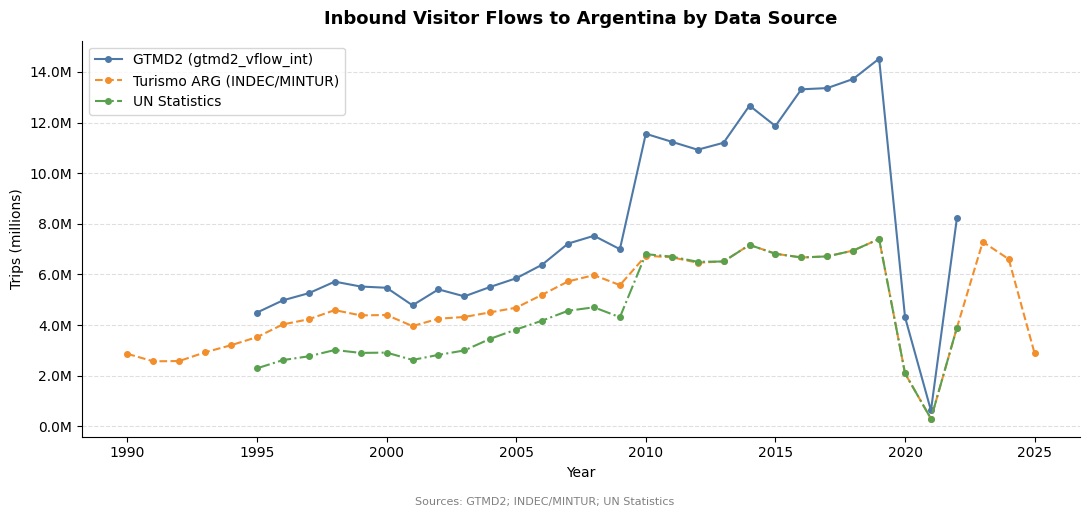

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))

sources = {
    "GTMD2 (gtmd2_vflow_int)":    (tabla["year"], tabla["gtmd2_trips"],       "#4E79A7", "solid"),
    "Turismo ARG (INDEC/MINTUR)": (tabla["year"], tabla["turismo_arg_trips"],  "#F28E2B", "dashed"),
    "UN Statistics":              (tabla["year"], tabla["un_trips"],           "#59A14F", "dashdot"),
}

for label, (x, y, color, ls) in sources.items():
    ax.plot(x, y / 1e6, marker="o", markersize=4, linewidth=1.5,
            color=color, linestyle=ls, label=label)

ax.set_title("Inbound Visitor Flows to Argentina by Data Source",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Year", fontsize=10)
ax.set_ylabel("Trips (millions)", fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}M"))
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

fig.text(0.5, -0.02, "Sources: GTMD2; INDEC/MINTUR; UN Statistics",
         ha="center", fontsize=8, color="gray")

plt.tight_layout()
plt.show()

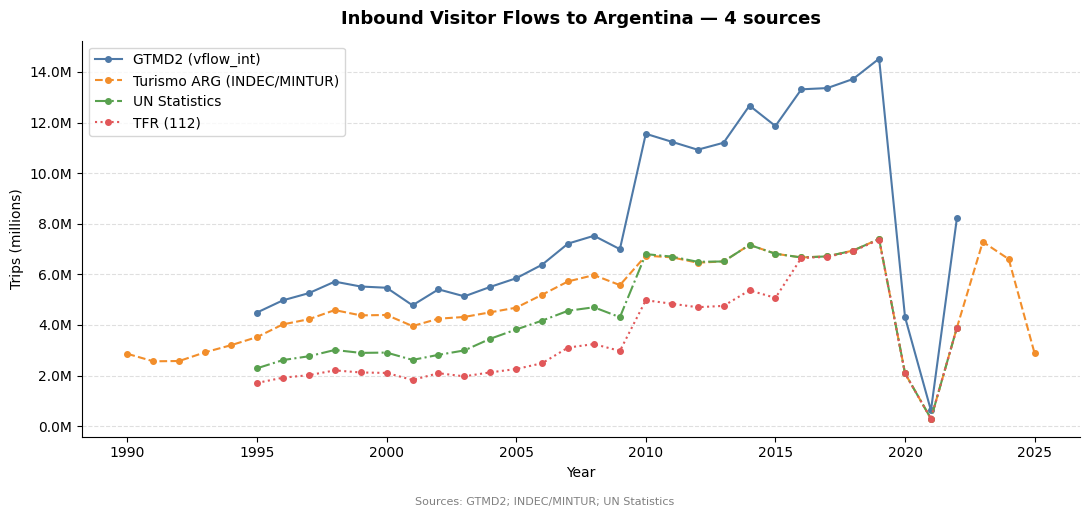

In [11]:
plot_gtmd2(
    tabla_ext,
    [
        ("gtmd2_trips",       "GTMD2 (vflow_int)",          "#4E79A7", "solid"),
        ("turismo_arg_trips", "Turismo ARG (INDEC/MINTUR)",  "#F28E2B", "dashed"),
        ("un_trips",          "UN Statistics",               "#59A14F", "dashdot"),
        ("unwto_tflow_112",   "TFR (112)",                   "#E15759", "dotted"),
    ],
    "Inbound Visitor Flows to Argentina — 4 sources",
    caption="Sources: GTMD2; INDEC/MINTUR; UN Statistics",
)

## Comparacion de datos con otros paises BRA CHL y ESPAÑA

In [12]:
def tabla_gtmd2_pais(iso3):
    """Tabla anual de flujos GTMD2 hacia un país destino."""
    cols_flow = ["gtmd2_vflow_int"] + unwto_vars

    df = (
        gtmd2[
            (gtmd2["iso3code_j"] == iso3) &
            (gtmd2["iso3code_i"] != iso3)
        ]
        .groupby("year")[cols_flow]
        .sum(min_count=1)
        .reset_index()
        .sort_values("year")
        .reset_index(drop=True)
    )

    df_fmt = df.copy()
    for col in cols_flow:
        df_fmt[col] = df_fmt[col].apply(
            lambda x: f"{int(x):,}" if pd.notna(x) else "—"
        )

    df_fmt.columns = [
        "Year", "GTMD2 (vflow_int)",
        "TFN (111)", "TFR (112)", "VFN (121)", "VFR (122)",
        "711", "712", "1911", "1912",
    ]
    return df_fmt

### Brasil

In [13]:
tabla_gtmd2_pais("BRA")

,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"3,289,158",—,"1,937,974",—,—,—,—,—,—
1,1996,"4,292,792",—,"2,590,187",—,—,—,—,—,—
2,1997,"4,606,812",—,"2,771,073",—,—,—,—,—,—
3,1998,"7,834,147",—,"4,676,472",—,—,—,—,—,—
4,1999,"8,247,167",—,"4,959,423",—,—,—,—,—,—
5,2000,"8,540,460",—,"5,200,111",—,—,—,—,—,—
6,2001,"7,438,531",—,"4,664,710",—,—,—,—,—,—
7,2002,"5,517,290",—,"3,720,535",—,—,—,—,—,—
8,2003,"5,886,396",—,"4,020,235",—,—,—,—,—,—
9,2004,"6,747,881",—,"4,644,081",—,—,—,—,—,—


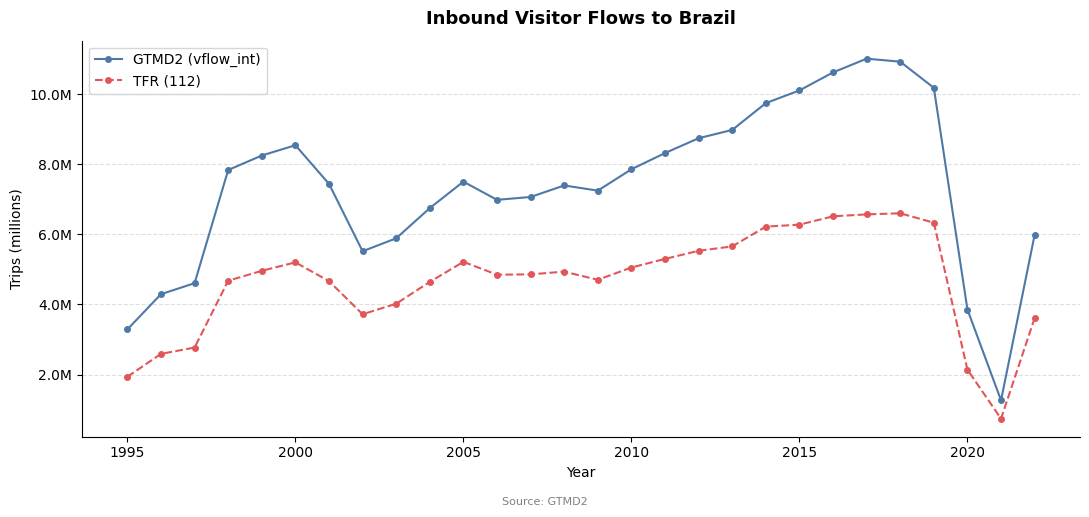

In [14]:
plot_gtmd2(
    gtmd2_pais_data("BRA", ["gtmd2_vflow_int", "unwto_tflow_112"]),
    [
        ("gtmd2_vflow_int",  "GTMD2 (vflow_int)", "#4E79A7", "solid"),
        ("unwto_tflow_112",  "TFR (112)",          "#E15759", "dashed"),
    ],
    "Inbound Visitor Flows to Brazil",
)

### Chile

In [15]:
tabla_gtmd2_pais("CHL")

,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"3,282,973","1,500,492",—,—,—,—,—,—,—
1,1996,"3,044,053","1,415,889",—,—,—,—,—,—,—
2,1997,"3,457,458","1,641,589",—,—,—,—,—,—,—
3,1998,"3,668,586","1,756,771",—,—,—,—,—,—,—
4,1999,"3,398,767","1,625,019",—,—,—,—,—,—,—
5,2000,"3,611,833","1,731,697",—,—,—,—,—,—,—
6,2001,"3,552,827","1,718,490",—,—,—,—,—,—,—
7,2002,"2,793,194","1,408,681",—,—,—,—,—,—,—
8,2003,"3,091,442","1,609,072",—,—,—,—,—,—,—
9,2004,"3,367,458","1,777,089",—,—,—,—,—,—,—


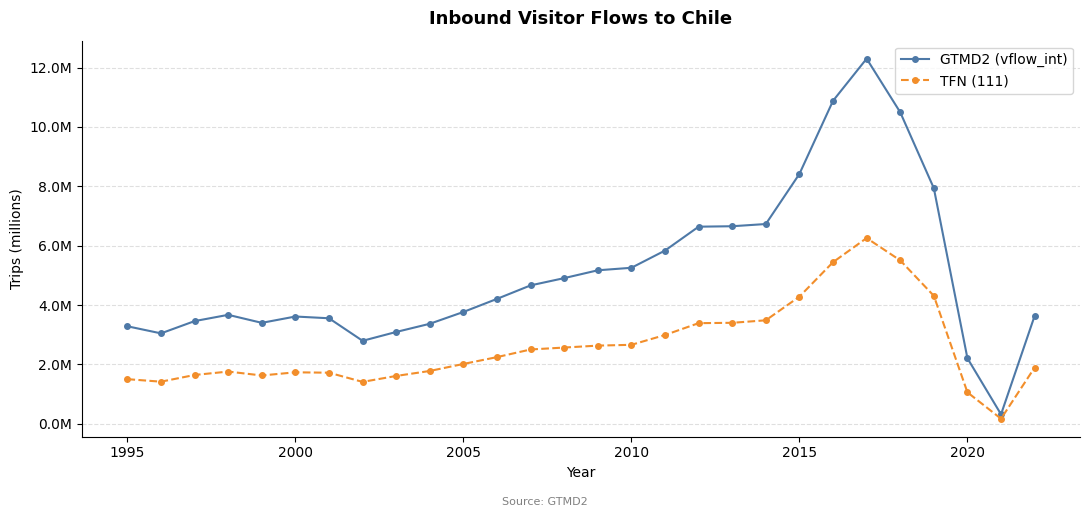

In [16]:
plot_gtmd2(
    gtmd2_pais_data("CHL", ["gtmd2_vflow_int", "unwto_tflow_111"]),
    [
        ("gtmd2_vflow_int",  "GTMD2 (vflow_int)", "#4E79A7", "solid"),
        ("unwto_tflow_111",  "TFN (111)",          "#F28E2B", "dashed"),
    ],
    "Inbound Visitor Flows to Chile",
)

### España

In [17]:
tabla_gtmd2_pais("ESP")

,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"53,423,105",—,—,—,—,—,"14,540,170",—,"15,650,223"
1,1996,"53,850,395",—,—,—,—,—,"15,074,185",—,"16,143,726"
2,1997,"45,075,312",—,"36,855,501",—,—,—,"16,311,975",—,"17,562,362"
3,1998,"47,528,628",—,"39,093,478",—,—,—,"18,078,047",—,"19,485,051"
4,1999,"51,659,819",—,"42,319,119",—,—,—,"24,299,918",—,"25,972,562"
5,2000,"52,870,383",—,"42,758,260",—,—,—,"24,358,534",—,"33,900,022"
6,2001,"56,179,128",—,"45,863,941",—,—,—,"24,134,885",—,"33,212,526"
7,2002,"59,486,087",—,"47,862,442",—,—,—,"23,825,836",—,"33,091,130"
8,2003,"59,925,767",—,"48,435,568",—,—,—,"24,545,904",—,"33,755,163"
9,2004,"61,178,487",—,"49,658,930",—,—,—,"24,791,018",—,"33,278,990"


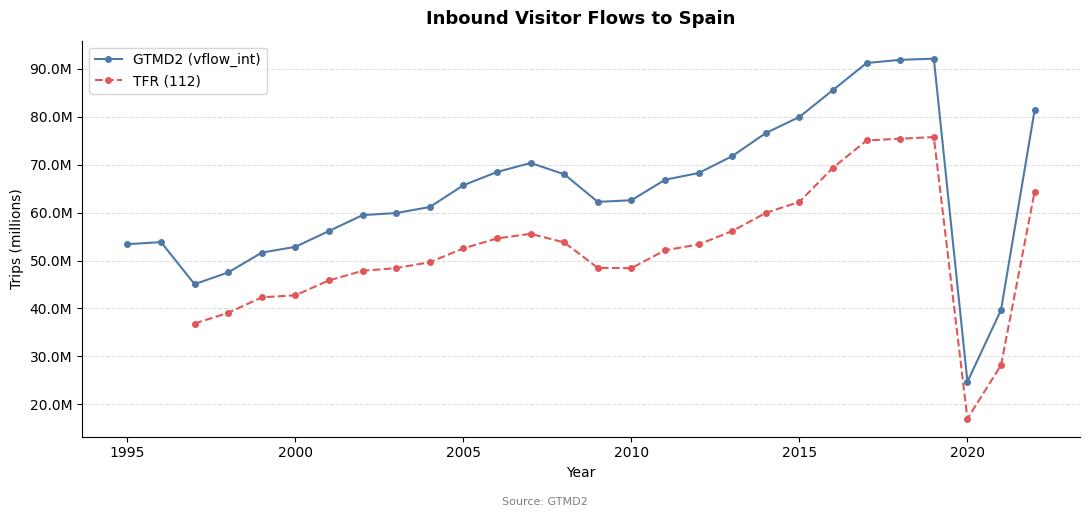

In [18]:
plot_gtmd2(
    gtmd2_pais_data("ESP", ["gtmd2_vflow_int", "unwto_tflow_112"]),
    [
        ("gtmd2_vflow_int",  "GTMD2 (vflow_int)", "#4E79A7", "solid"),
        ("unwto_tflow_112",  "TFR (112)",          "#E15759", "dashed"),
    ],
    "Inbound Visitor Flows to Spain",
)

## Analisis por pais de origen

In [19]:
# Misma definición que en los R files
south_america = [
    'ARG', 'BOL', 'BRA', 'CHL', 'COL', 'ECU',
    'GUY', 'PRY', 'PER', 'SUR', 'URY', 'VEN'
]

central_caribbean = [
    'BLZ', 'CRI', 'SLV', 'GTM', 'HND', 'NIC', 'PAN', 'MEX',
    'CUB', 'DOM', 'HTI', 'JAM', 'TTO', 'BRB', 'BHS', 'GRD',
    'LCA', 'VCT', 'ATG', 'KNA', 'DMA', 'SLB'
]

latin_america = south_america + central_caribbean

## Análisis por corredor: origen → Argentina

### Bolivia → Argentina

In [20]:
orig = "BOL"
dest = "ARG"

# GTMD2: vflow_int y TFR (112)
s_gtmd2 = (
    gtmd2[
        (gtmd2["iso3code_i"] == orig) &
        (gtmd2["iso3code_j"] == dest)
    ]
    [["year", "gtmd2_vflow_int", "unwto_tflow_112"]]
    .rename(columns={"gtmd2_vflow_int": "gtmd2", "unwto_tflow_112": "tfr_112"})
)

# Turismo ARG (INDEC/MINTUR)
s_turismo = (
    turismo_arg[turismo_arg["iso3code_i"] == orig]
    .groupby("year")["trips"]
    .sum()
    .reset_index()
    .rename(columns={"trips": "turismo_arg"})
)

# UN Latam
s_un = un_latam[un_latam["iso3code_i"] == orig][["year", "un_latam_trips"]]

# Unir las 4 fuentes
tabla_bol_arg = (
    s_gtmd2
    .merge(s_turismo, on="year", how="outer")
    .merge(s_un,      on="year", how="outer")
    .sort_values("year")
    .reset_index(drop=True)
)

# Mostrar formateada
tabla_bol_arg_fmt = tabla_bol_arg.copy()
for col in ["gtmd2", "tfr_112", "turismo_arg", "un_latam_trips"]:
    tabla_bol_arg_fmt[col] = tabla_bol_arg_fmt[col].apply(
        lambda x: f"{int(x):,}" if pd.notna(x) else "—"
    )
tabla_bol_arg_fmt.columns = ["Year", "GTMD2 (vflow_int)", "TFR (112)", "Turismo ARG (INDEC/MINTUR)", "UN Statistics"]
tabla_bol_arg_fmt

,Year,GTMD2 (vflow_int),TFR (112),Turismo ARG (INDEC/MINTUR),UN Statistics
0,1990,—,—,"136,857",—
1,1991,—,—,"144,091",—
2,1992,—,—,"151,061",—
3,1993,—,—,"137,885",—
4,1994,—,—,"178,083",—
5,1995,"292,392","123,699","190,514","123,699"
6,1996,"283,817","119,842","185,470","119,842"
7,1997,"334,962","142,949","221,924","142,949"
8,1998,"337,302","144,012","221,788","144,012"
9,1999,"243,300","101,724","156,546","101,724"


Si vemos el corredor BOL-> ARG los datos de TFR112 y UN Statitics (tomados a mano desde el excel original) aqui coinciden al 100% e la agregación a nivel de pais destino hay algunas diferencias. Luego comparo LATAM

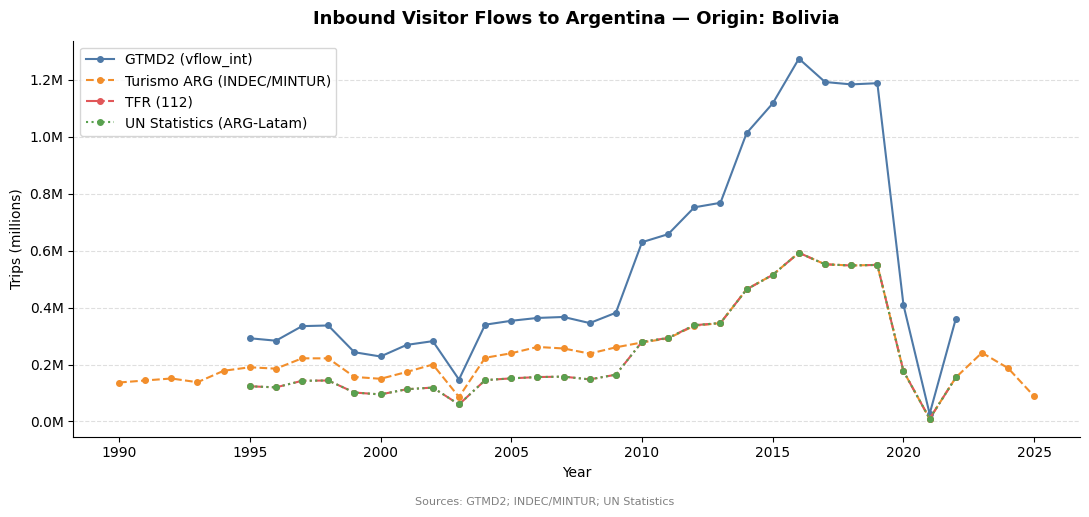

In [21]:
plot_gtmd2(
    tabla_bol_arg,
    [
        ("gtmd2",          "GTMD2 (vflow_int)",          "#4E79A7", "solid"),
        ("turismo_arg",    "Turismo ARG (INDEC/MINTUR)",  "#F28E2B", "dashed"),
        ("tfr_112",        "TFR (112)",                   "#E15759", "dashdot"),
        ("un_latam_trips", "UN Statistics (ARG-Latam)",   "#59A14F", "dotted"),
    ],
    "Inbound Visitor Flows to Argentina — Origin: Bolivia",
    caption="Sources: GTMD2; INDEC/MINTUR; UN Statistics",
)

### Venezuela → Argentina

In [22]:
orig = "VEN"
dest = "ARG"

# GTMD2: vflow_int y TFR (112)
s_gtmd2 = (
    gtmd2[
        (gtmd2["iso3code_i"] == orig) &
        (gtmd2["iso3code_j"] == dest)
    ]
    [["year", "gtmd2_vflow_int", "unwto_tflow_112"]]
    .rename(columns={"gtmd2_vflow_int": "gtmd2", "unwto_tflow_112": "tfr_112"})
)

# Turismo ARG (INDEC/MINTUR)
s_turismo = (
    turismo_arg[turismo_arg["iso3code_i"] == orig]
    .groupby("year")["trips"]
    .sum()
    .reset_index()
    .rename(columns={"trips": "turismo_arg"})
)

# UN Latam
s_un = un_latam[un_latam["iso3code_i"] == orig][["year", "un_latam_trips"]]

# Unir las 4 fuentes
tabla_ven_arg = (
    s_gtmd2
    .merge(s_turismo, on="year", how="outer")
    .merge(s_un,      on="year", how="outer")
    .sort_values("year")
    .reset_index(drop=True)
)

# Mostrar formateada
tabla_ven_arg_fmt = tabla_ven_arg.copy()
for col in ["gtmd2", "tfr_112", "turismo_arg", "un_latam_trips"]:
    tabla_ven_arg_fmt[col] = tabla_ven_arg_fmt[col].apply(
        lambda x: f"{int(x):,}" if pd.notna(x) else "—"
    )
tabla_ven_arg_fmt.columns = ["Year", "GTMD2 (vflow_int)", "TFR (112)", "Turismo ARG (INDEC/MINTUR)", "UN Statistics"]
tabla_ven_arg_fmt

,Year,GTMD2 (vflow_int),TFR (112),Turismo ARG (INDEC/MINTUR),UN Statistics
0,1995,—,—,—,—
1,1996,—,—,—,—
2,1997,—,—,—,—
3,1998,—,—,—,—
4,1999,—,—,—,—
5,2000,—,—,—,—
6,2001,—,—,—,—
7,2002,—,—,—,—
8,2003,—,—,—,—
9,2004,—,—,—,—


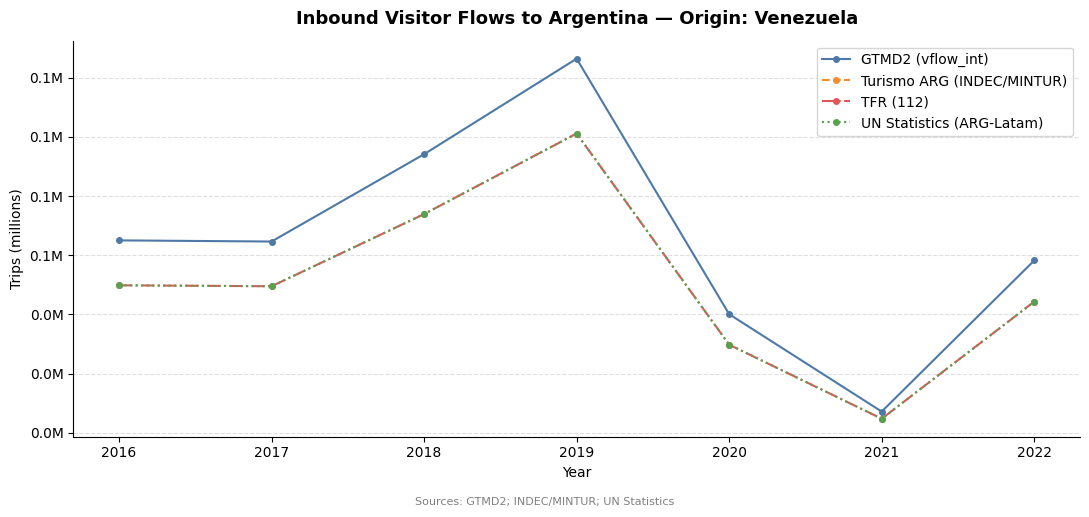

In [23]:
plot_gtmd2(
    tabla_ven_arg,
    [
        ("gtmd2",          "GTMD2 (vflow_int)",          "#4E79A7", "solid"),
        ("turismo_arg",    "Turismo ARG (INDEC/MINTUR)",  "#F28E2B", "dashed"),
        ("tfr_112",        "TFR (112)",                   "#E15759", "dashdot"),
        ("un_latam_trips", "UN Statistics (ARG-Latam)",   "#59A14F", "dotted"),
    ],
    "Inbound Visitor Flows to Argentina — Origin: Venezuela",
    caption="Sources: GTMD2; INDEC/MINTUR; UN Statistics",
)

## Análisis para todos los países de Sudamérica → Argentina

In [24]:
UNWTO_COLS = {
    "unwto_tflow_111":  "TFN (111)",
    "unwto_tflow_112":  "TFR (112)",
    "unwto_tflow_121":  "VFN (121)",
    "unwto_tflow_122":  "VFR (122)",
    "unwto_tflow_711":  "711",
    "unwto_tflow_712":  "712",
    "unwto_tflow_1911": "1911",
    "unwto_tflow_1912": "1912",
}

def build_corredor(orig, dest="ARG"):
    """
    Construye tabla comparativa de viajes orig → dest combinando:
      - GTMD2 (gtmd2_vflow_int) + todas las columnas UNWTO  siempre
      - Turismo ARG INDEC/MINTUR                             solo si dest="ARG" y orig tiene mapeo
      - UN Latam                                             solo si dest="ARG" y orig está en un_latam
    """
    fetch_cols = ["year", "gtmd2_vflow_int"] + list(UNWTO_COLS.keys())
    s_gtmd2 = (
        gtmd2[
            (gtmd2["iso3code_i"] == orig) &
            (gtmd2["iso3code_j"] == dest)
        ]
        [fetch_cols]
        .rename(columns={"gtmd2_vflow_int": "gtmd2"})
    )

    df = s_gtmd2.copy()

    if dest == "ARG":
        s_turismo = (
            turismo_arg[turismo_arg["iso3code_i"] == orig]
            .groupby("year")["trips"]
            .sum()
            .reset_index()
            .rename(columns={"trips": "turismo_arg"})
        )
        if not s_turismo.empty:
            df = df.merge(s_turismo, on="year", how="outer")
        else:
            df["turismo_arg"] = float("nan")

        s_un = un_latam[un_latam["iso3code_i"] == orig][["year", "un_latam_trips"]]
        if not s_un.empty:
            df = df.merge(s_un, on="year", how="outer")
        else:
            df["un_latam_trips"] = float("nan")

    return df.sort_values("year").reset_index(drop=True)


def show_corredor(orig, dest="ARG"):
    df = build_corredor(orig, dest)

    # ── Tabla formateada ──────────────────────────────────────────
    df_fmt = df.copy()
    num_cols = ["gtmd2"] + list(UNWTO_COLS.keys())
    if "turismo_arg"    in df_fmt.columns: num_cols.append("turismo_arg")
    if "un_latam_trips" in df_fmt.columns: num_cols.append("un_latam_trips")

    for col in num_cols:
        if col in df_fmt.columns:
            df_fmt[col] = df_fmt[col].apply(
                lambda x: f"{int(x):,}" if pd.notna(x) else "—"
            )

    rename_map = {"year": "Year", "gtmd2": "GTMD2 (vflow_int)",
                  "turismo_arg": "Turismo ARG (INDEC/MINTUR)",
                  "un_latam_trips": "UN Statistics"}
    rename_map.update(UNWTO_COLS)
    df_fmt = df_fmt.rename(columns=rename_map)
    display(df_fmt)

    # ── Gráfico: auto-detectar la columna UNWTO con datos ─────────
    unwto_with_data = [col for col in UNWTO_COLS if col in df.columns and df[col].notna().any()]
    unwto_to_plot   = unwto_with_data[0] if unwto_with_data else None

    COLORS_UNWTO = ["#E15759", "#76B7B2", "#FF9DA7", "#9C755F", "#BAB0AC"]
    series_cfg = [("gtmd2", "GTMD2 (vflow_int)", "#4E79A7", "solid")]

    if "turismo_arg" in df.columns and df["turismo_arg"].notna().any():
        series_cfg.append(("turismo_arg", "Turismo ARG (INDEC/MINTUR)", "#F28E2B", "dashed"))

    for i, col in enumerate(unwto_with_data):
        series_cfg.append((col, UNWTO_COLS[col], COLORS_UNWTO[i % len(COLORS_UNWTO)], "dashdot"))

    if "un_latam_trips" in df.columns and df["un_latam_trips"].notna().any():
        series_cfg.append(("un_latam_trips", "UN Statistics (ARG-Latam)", "#59A14F", "dotted"))

    plot_gtmd2(
        df, series_cfg,
        f"Inbound Visitor Flows to {dest} — Origin: {orig}",
        caption="Sources: GTMD2; INDEC/MINTUR; UN Statistics",
    )



  BOL → ARG


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912,Turismo ARG (INDEC/MINTUR),UN Statistics
0,1990,—,—,—,—,—,—,—,—,—,"136,857",—
1,1991,—,—,—,—,—,—,—,—,—,"144,091",—
2,1992,—,—,—,—,—,—,—,—,—,"151,061",—
3,1993,—,—,—,—,—,—,—,—,—,"137,885",—
4,1994,—,—,—,—,—,—,—,—,—,"178,083",—
5,1995,"292,392",—,"123,699",—,—,—,—,—,—,"190,514","123,699"
6,1996,"283,817",—,"119,842",—,—,—,—,—,—,"185,470","119,842"
7,1997,"334,962",—,"142,949",—,—,—,—,—,—,"221,924","142,949"
8,1998,"337,302",—,"144,012",—,—,—,—,—,—,"221,788","144,012"
9,1999,"243,300",—,"101,724",—,—,—,—,—,—,"156,546","101,724"


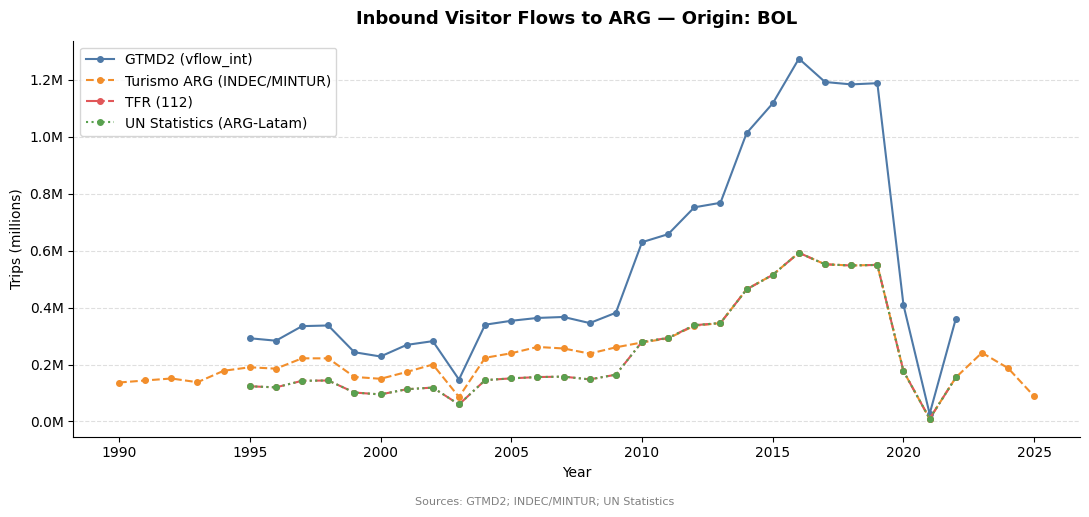


  BRA → ARG


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912,Turismo ARG (INDEC/MINTUR),UN Statistics
0,1990,—,—,—,—,—,—,—,—,—,"445,993",—
1,1991,—,—,—,—,—,—,—,—,—,"380,250",—
2,1992,—,—,—,—,—,—,—,—,—,"397,305",—
3,1993,—,—,—,—,—,—,—,—,—,"424,920",—
4,1994,—,—,—,—,—,—,—,—,—,"449,436",—
5,1995,"771,892",—,"316,784",—,—,—,—,—,—,"572,665","316,784"
6,1996,"988,314",—,"412,083",—,—,—,—,—,—,"748,332","412,083"
7,1997,"1,063,098",—,"445,343",—,—,—,—,—,—,"806,939","445,343"
8,1998,"1,173,783",—,"494,843",—,—,—,—,—,—,"892,569","494,843"
9,1999,"1,077,505",—,"451,768",—,—,—,—,—,—,"816,056","451,768"


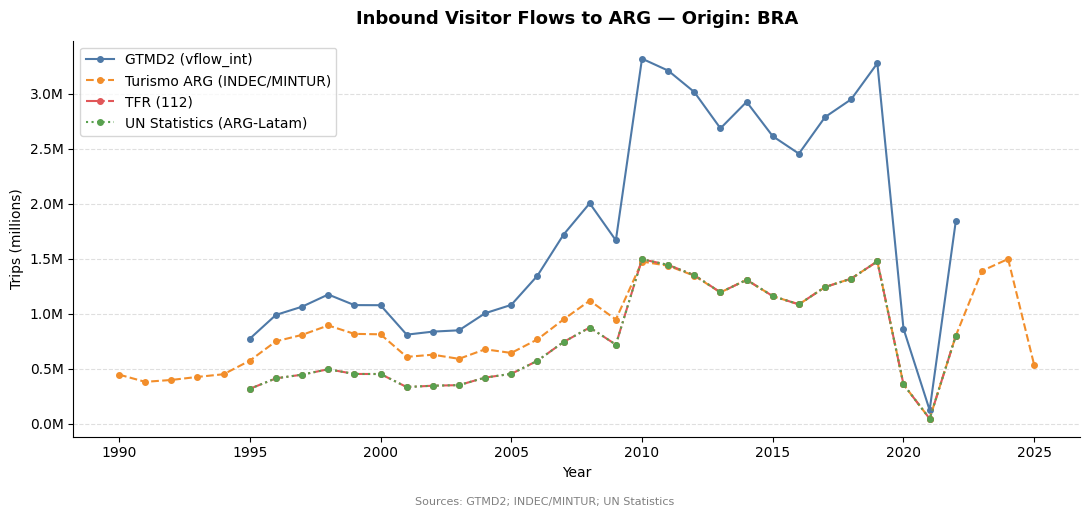


  CHL → ARG


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912,Turismo ARG (INDEC/MINTUR),UN Statistics
0,1990,—,—,—,—,—,—,—,—,—,"483,359",—
1,1991,—,—,—,—,—,—,—,—,—,"431,135",—
2,1992,—,—,—,—,—,—,—,—,—,"410,847",—
3,1993,—,—,—,—,—,—,—,—,—,"483,278",—
4,1994,—,—,—,—,—,—,—,—,—,"508,055",—
5,1995,"1,244,582",—,"465,743",—,—,—,—,—,—,"512,845","465,743"
6,1996,"1,286,825",—,"482,583",—,—,—,—,—,—,"528,293","482,583"
7,1997,"1,284,470",—,"481,643",—,—,—,—,—,—,"529,701","481,643"
8,1998,"1,454,382",—,"549,718",—,—,—,—,—,—,"602,597","549,718"
9,1999,"1,433,104",—,"541,163",—,—,—,—,—,—,"593,904","541,163"


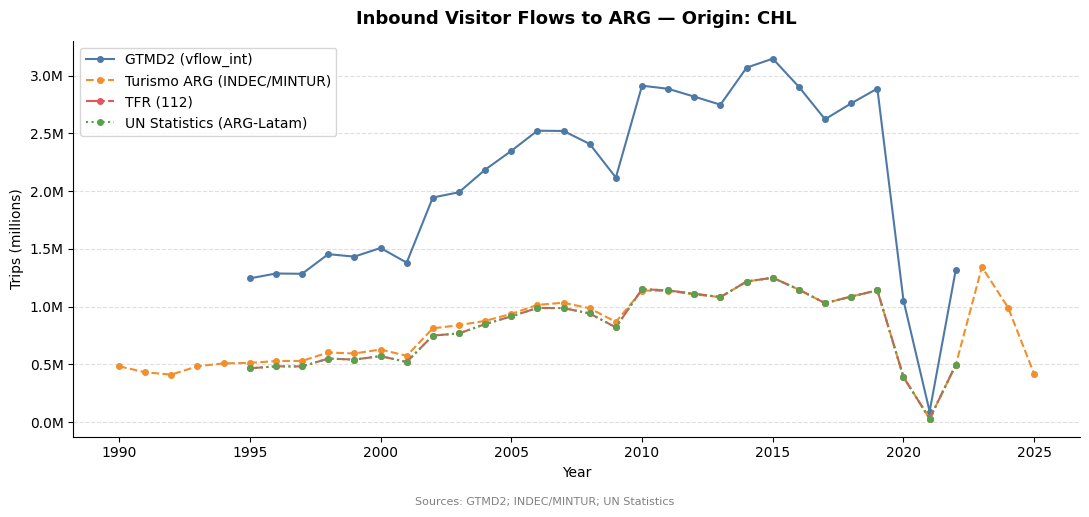


  COL → ARG


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912,Turismo ARG (INDEC/MINTUR),UN Statistics
0,1995,—,—,—,—,—,—,—,—,—,—,—
1,1996,—,—,—,—,—,—,—,—,—,—,—
2,1997,—,—,—,—,—,—,—,—,—,—,—
3,1998,—,—,—,—,—,—,—,—,—,—,—
4,1999,—,—,—,—,—,—,—,—,—,—,—
5,2000,—,—,—,—,—,—,—,—,—,—,—
6,2001,—,—,—,—,—,—,—,—,—,—,—
7,2002,—,—,—,—,—,—,—,—,—,—,—
8,2003,—,—,—,—,—,—,—,—,—,—,—
9,2004,—,—,—,—,—,—,—,—,—,—,—


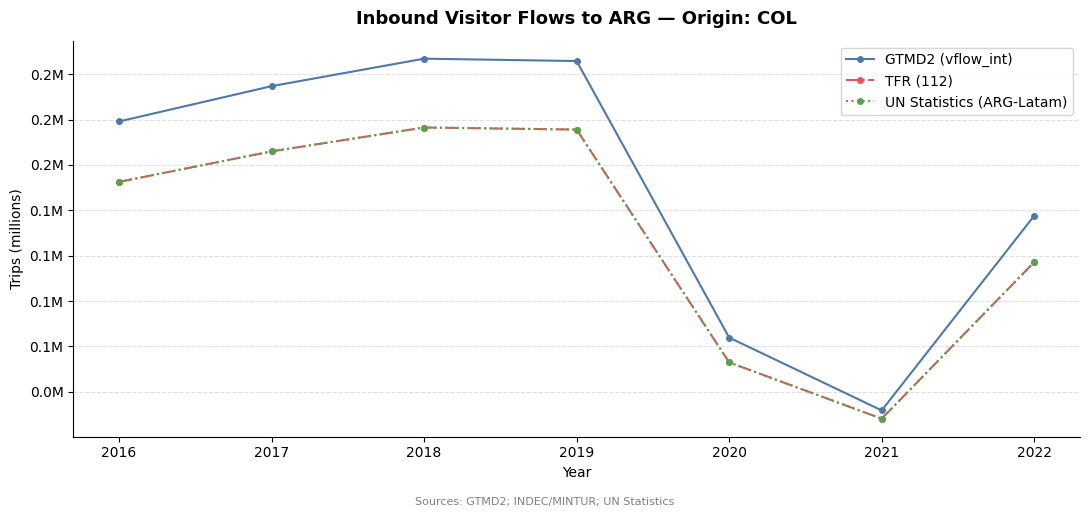


  ECU → ARG


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912,Turismo ARG (INDEC/MINTUR),UN Statistics
0,1995,—,—,—,—,—,—,—,—,—,—,—
1,1996,—,—,—,—,—,—,—,—,—,—,—
2,1997,—,—,—,—,—,—,—,—,—,—,—
3,1998,—,—,—,—,—,—,—,—,—,—,—
4,1999,—,—,—,—,—,—,—,—,—,—,—
5,2000,—,—,—,—,—,—,—,—,—,—,—
6,2001,—,—,—,—,—,—,—,—,—,—,—
7,2002,—,—,—,—,—,—,—,—,—,—,—
8,2003,—,—,—,—,—,—,—,—,—,—,—
9,2004,—,—,—,—,—,—,—,—,—,—,—


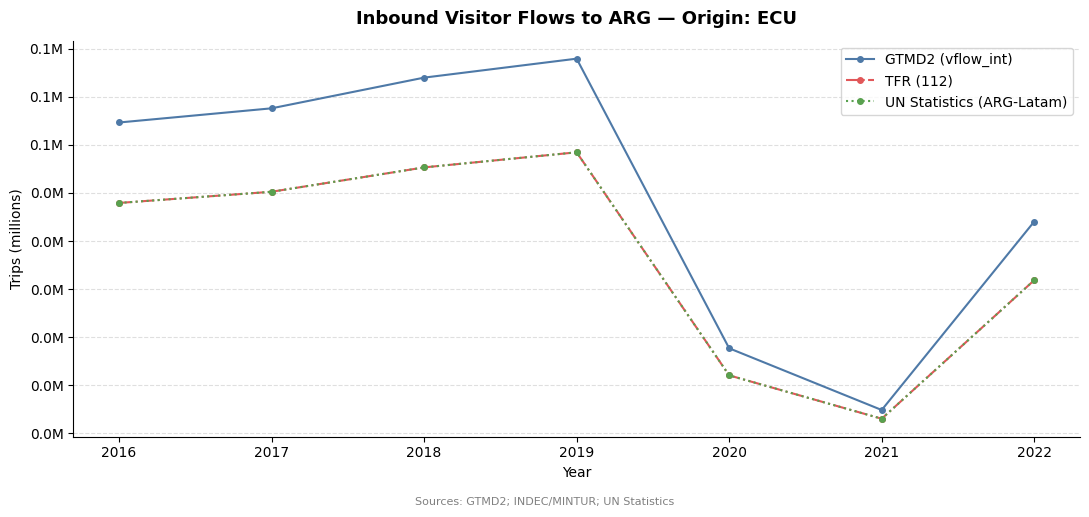


  GUY → ARG


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912,Turismo ARG (INDEC/MINTUR),UN Statistics
0,1995,—,—,—,—,—,—,—,—,—,—,—
1,1996,—,—,—,—,—,—,—,—,—,—,—
2,1997,—,—,—,—,—,—,—,—,—,—,—
3,1998,—,—,—,—,—,—,—,—,—,—,—
4,1999,—,—,—,—,—,—,—,—,—,—,—
5,2000,—,—,—,—,—,—,—,—,—,—,—
6,2001,—,—,—,—,—,—,—,—,—,—,—
7,2002,—,—,—,—,—,—,—,—,—,—,—
8,2003,—,—,—,—,—,—,—,—,—,—,—
9,2004,—,—,—,—,—,—,—,—,—,—,—


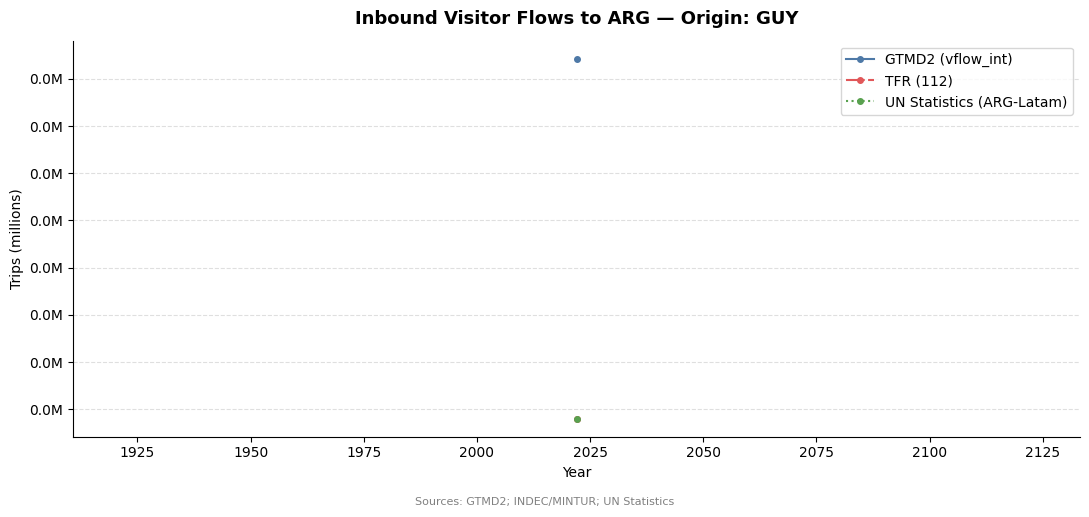


  PRY → ARG


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912,Turismo ARG (INDEC/MINTUR),UN Statistics
0,1990,—,—,—,—,—,—,—,—,—,"512,245",—
1,1991,—,—,—,—,—,—,—,—,—,"549,642",—
2,1992,—,—,—,—,—,—,—,—,—,"570,977",—
3,1993,—,—,—,—,—,—,—,—,—,"748,756",—
4,1994,—,—,—,—,—,—,—,—,—,"854,958",—
5,1995,"1,005,543",—,"415,945",—,—,—,—,—,—,"893,148","415,945"
6,1996,"1,210,278",—,"506,619",—,—,—,—,—,—,"1,031,969","506,619"
7,1997,"1,066,120",—,"442,660",—,—,—,—,—,—,"920,012","442,660"
8,1998,"1,170,977",—,"489,131",—,—,—,—,—,—,"1,000,310","489,131"
9,1999,"1,231,134",—,"515,914",—,—,—,—,—,—,"1,009,584","515,914"


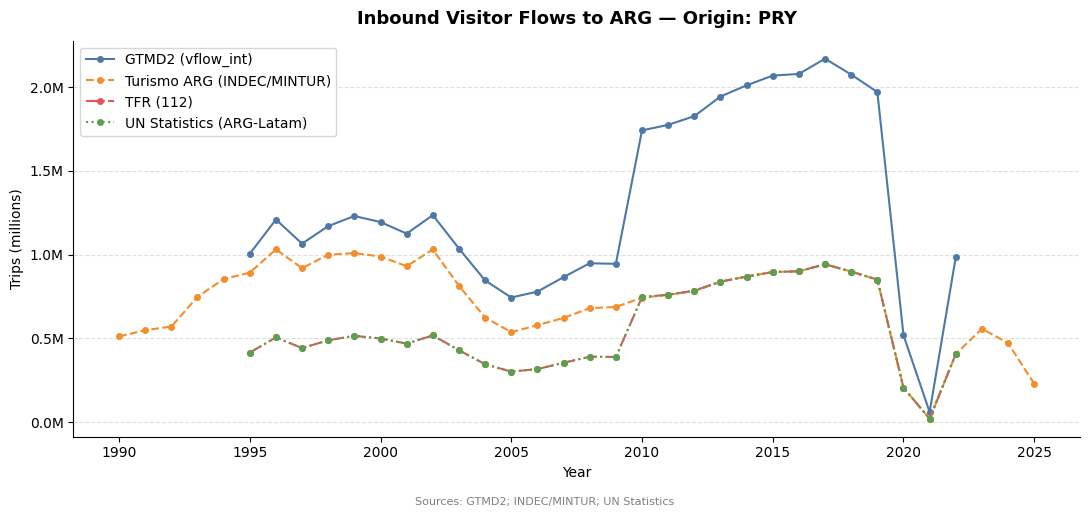


  PER → ARG


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912,Turismo ARG (INDEC/MINTUR),UN Statistics
0,1995,—,—,—,—,—,—,—,—,—,—,—
1,1996,—,—,—,—,—,—,—,—,—,—,—
2,1997,—,—,—,—,—,—,—,—,—,—,—
3,1998,—,—,—,—,—,—,—,—,—,—,—
4,1999,—,—,—,—,—,—,—,—,—,—,—
5,2000,—,—,—,—,—,—,—,—,—,—,—
6,2001,—,—,—,—,—,—,—,—,—,—,—
7,2002,—,—,—,—,—,—,—,—,—,—,—
8,2003,—,—,—,—,—,—,—,—,—,—,—
9,2004,—,—,—,—,—,—,—,—,—,—,—


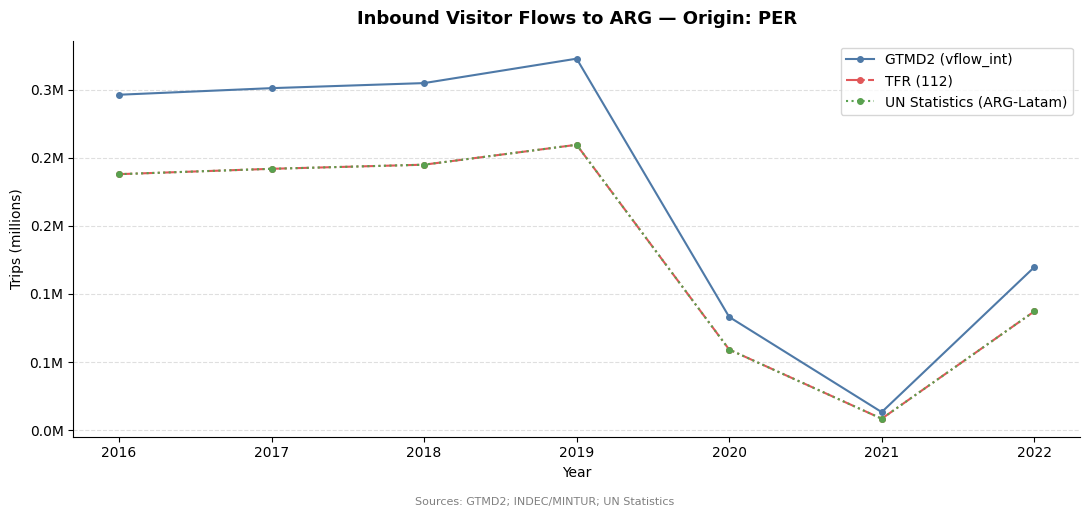


  SUR → ARG


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912,Turismo ARG (INDEC/MINTUR),UN Statistics
0,1995,—,—,—,—,—,—,—,—,—,—,—
1,1996,—,—,—,—,—,—,—,—,—,—,—
2,1997,—,—,—,—,—,—,—,—,—,—,—
3,1998,—,—,—,—,—,—,—,—,—,—,—
4,1999,—,—,—,—,—,—,—,—,—,—,—
5,2000,—,—,—,—,—,—,—,—,—,—,—
6,2001,—,—,—,—,—,—,—,—,—,—,—
7,2002,—,—,—,—,—,—,—,—,—,—,—
8,2003,—,—,—,—,—,—,—,—,—,—,—
9,2004,—,—,—,—,—,—,—,—,—,—,—


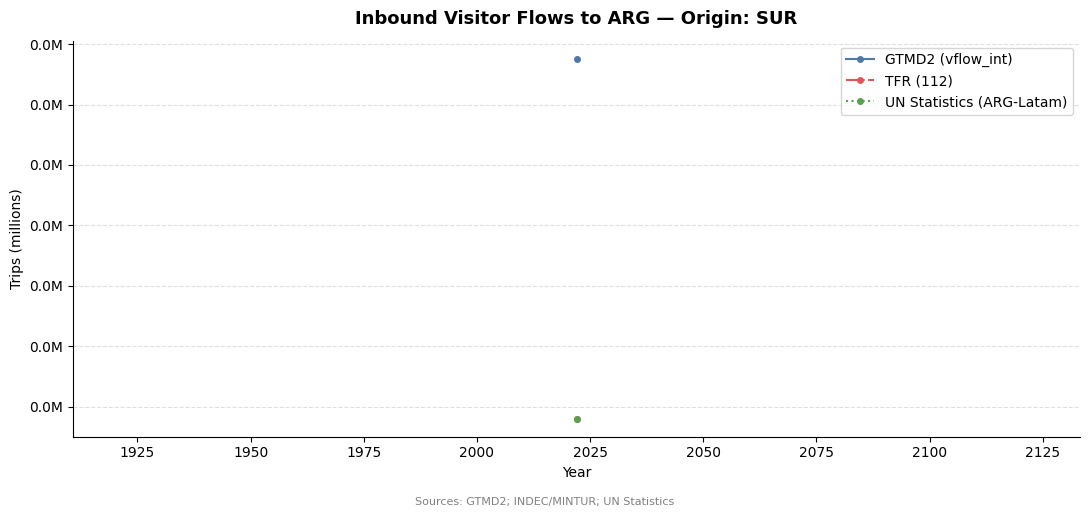


  URY → ARG


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912,Turismo ARG (INDEC/MINTUR),UN Statistics
0,1990,—,—,—,—,—,—,—,—,—,"530,296",—
1,1991,—,—,—,—,—,—,—,—,—,"410,693",—
2,1992,—,—,—,—,—,—,—,—,—,"388,432",—
3,1993,—,—,—,—,—,—,—,—,—,"479,411",—
4,1994,—,—,—,—,—,—,—,—,—,"485,792",—
5,1995,"1,177,748",—,"387,328",—,—,—,—,—,—,"532,191","387,328"
6,1996,"1,205,758",—,"397,138",—,—,—,—,—,—,"544,968","397,138"
7,1997,"1,509,485",—,"504,390",—,—,—,—,—,—,"692,748","504,390"
8,1998,"1,577,150",—,"528,484",—,—,—,—,—,—,"727,956","528,484"
9,1999,"1,535,792",—,"513,749",—,—,—,—,—,—,"705,774","513,749"


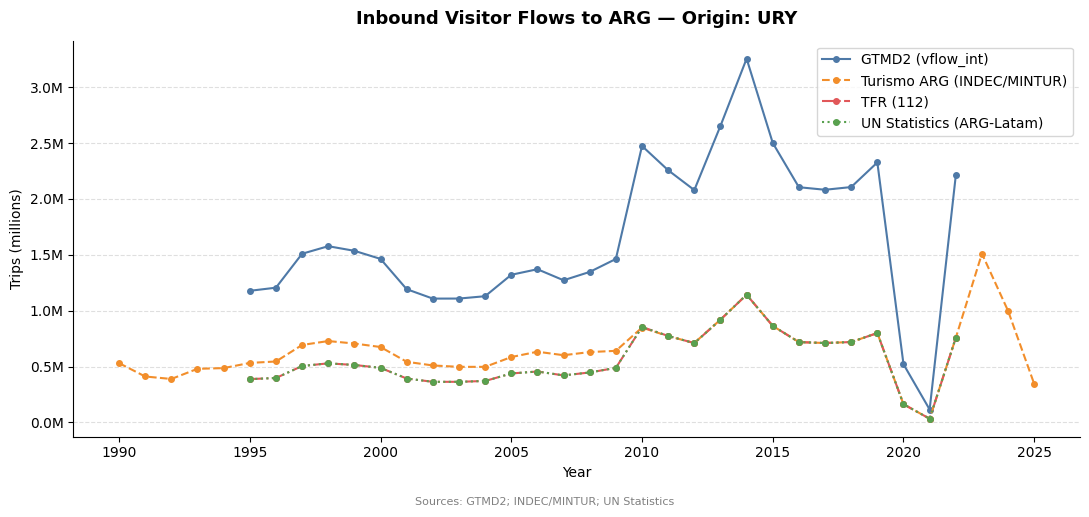


  VEN → ARG


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912,Turismo ARG (INDEC/MINTUR),UN Statistics
0,1995,—,—,—,—,—,—,—,—,—,—,—
1,1996,—,—,—,—,—,—,—,—,—,—,—
2,1997,—,—,—,—,—,—,—,—,—,—,—
3,1998,—,—,—,—,—,—,—,—,—,—,—
4,1999,—,—,—,—,—,—,—,—,—,—,—
5,2000,—,—,—,—,—,—,—,—,—,—,—
6,2001,—,—,—,—,—,—,—,—,—,—,—
7,2002,—,—,—,—,—,—,—,—,—,—,—
8,2003,—,—,—,—,—,—,—,—,—,—,—
9,2004,—,—,—,—,—,—,—,—,—,—,—


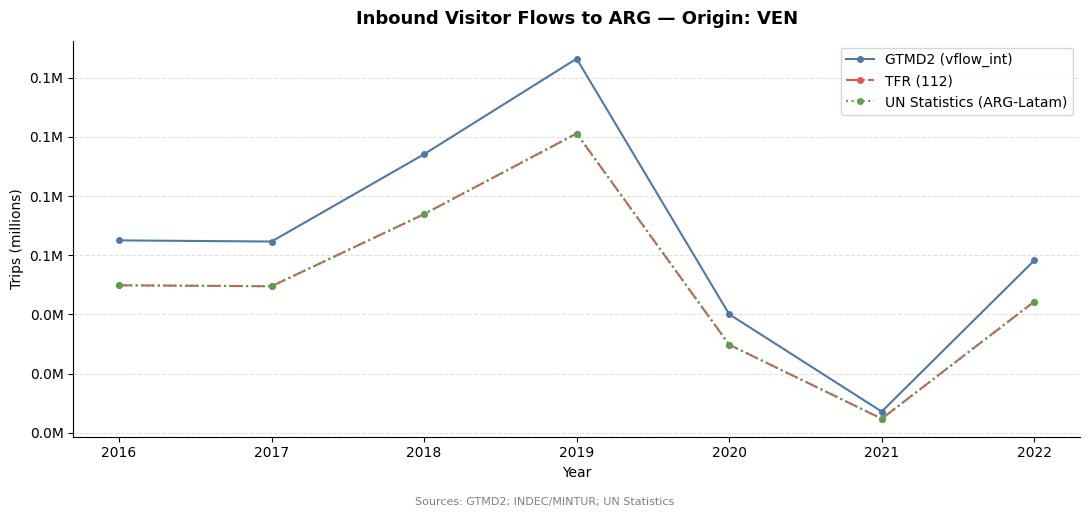

In [25]:
# Todos los países de Sudamérica hacia Argentina (excluye ARG como origen)
sa_origins = [c for c in south_america if c != "ARG"]

for orig in sa_origins:
    print(f"\n{'='*60}")
    print(f"  {orig} → ARG")
    print(f"{'='*60}")
    show_corredor(orig, dest="ARG")


## USA + Canadá → Argentina

`turismo_arg` agrupa ambos países como "EE.UU. y Canadá", así que sumamos USA + CAN en GTMD2 y TFR(112) para que sea comparable. `un_latam` no cubre ninguno de los dos.

,Year,GTMD2 (vflow_int),TFR (112),Turismo ARG (INDEC/MINTUR),UN Statistics
0,1990,—,—,"217,547",NaN
1,1991,—,—,"186,529",NaN
2,1992,—,—,"189,647",NaN
3,1993,—,—,"186,224",NaN
4,1994,—,—,"213,767",NaN
5,1995,—,—,"240,737",NaN
6,1996,—,—,"298,548",NaN
7,1997,—,—,"327,064",NaN
8,1998,—,—,"355,563",NaN
9,1999,—,—,"336,588",NaN


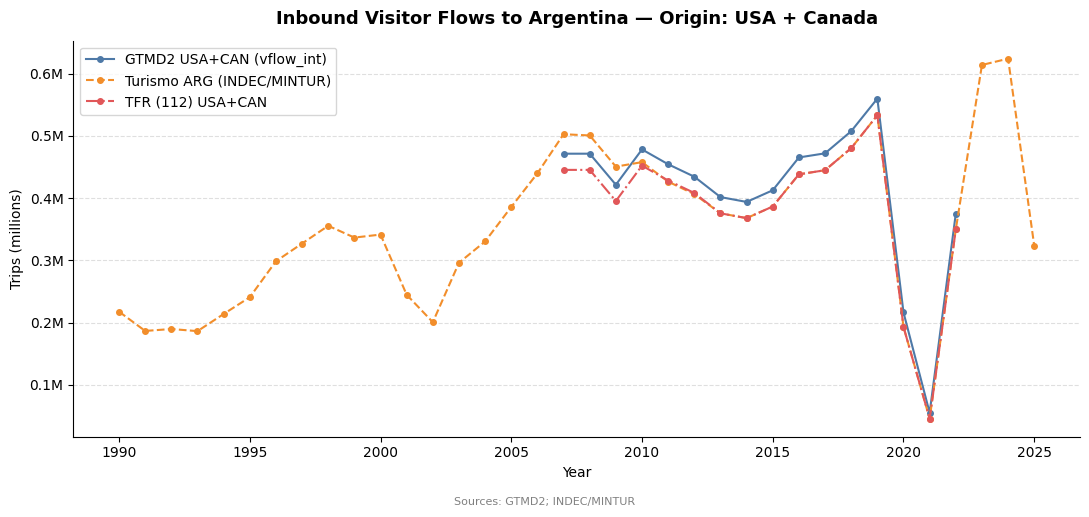

In [26]:
dest = "ARG"

# GTMD2: suma USA + CAN hacia ARG
s_gtmd2_uscan = (
    gtmd2[
        (gtmd2["iso3code_i"].isin(["USA", "CAN"])) &
        (gtmd2["iso3code_j"] == dest)
    ]
    .groupby("year")[["gtmd2_vflow_int", "unwto_tflow_112"]]
    .sum(min_count=1)
    .reset_index()
    .rename(columns={"gtmd2_vflow_int": "gtmd2", "unwto_tflow_112": "tfr_112"})
)

# Turismo ARG: "EE.UU. y Canadá"
s_turismo_uscan = (
    turismo_arg[turismo_arg["country_group"] == "EE.UU. y Canadá"]
    .groupby("year")["trips"]
    .sum()
    .reset_index()
    .rename(columns={"trips": "turismo_arg"})
)

tabla_uscan = (
    s_gtmd2_uscan
    .merge(s_turismo_uscan, on="year", how="outer")
    .sort_values("year")
    .reset_index(drop=True)
)
tabla_uscan["un_latam_trips"] = float("nan")  # no disponible

# Tabla formateada
tabla_uscan_fmt = tabla_uscan.copy()
for col in ["gtmd2", "tfr_112", "turismo_arg"]:
    tabla_uscan_fmt[col] = tabla_uscan_fmt[col].apply(
        lambda x: f"{int(x):,}" if pd.notna(x) else "—"
    )
tabla_uscan_fmt.columns = ["Year", "GTMD2 (vflow_int)", "TFR (112)", "Turismo ARG (INDEC/MINTUR)", "UN Statistics"]
display(tabla_uscan_fmt)

# Gráfico
plot_gtmd2(
    tabla_uscan,
    [
        ("gtmd2",       "GTMD2 USA+CAN (vflow_int)",   "#4E79A7", "solid"),
        ("turismo_arg", "Turismo ARG (INDEC/MINTUR)",   "#F28E2B", "dashed"),
        ("tfr_112",     "TFR (112) USA+CAN",            "#E15759", "dashdot"),
    ],
    "Inbound Visitor Flows to Argentina — Origin: USA + Canada",
    caption="Sources: GTMD2; INDEC/MINTUR",
)


## Sudamérica total → Argentina (todos los países sumados)

* Turismo ARG solo incluye: BOL, BRA, CHL, PRY, URY (únicos con mapeo individual)


,Year,GTMD2 (vflow_int),TFR (112),Turismo ARG (INDEC/MINTUR)*,UN Statistics
0,1990,—,—,"2,108,750",—
1,1991,—,—,"1,915,811",—
2,1992,—,—,"1,918,622",—
3,1993,—,—,"2,274,250",—
4,1994,—,—,"2,476,324",—
5,1995,"4,492,160","1,709,499","2,701,363","1,709,499"
6,1996,"4,974,994","1,918,265","3,039,032","1,918,265"
7,1997,"5,258,138","2,016,985","3,171,324","2,016,985"
8,1998,"5,713,596","2,206,188","3,445,220","2,206,188"
9,1999,"5,520,836","2,124,318","3,281,864","2,124,318"


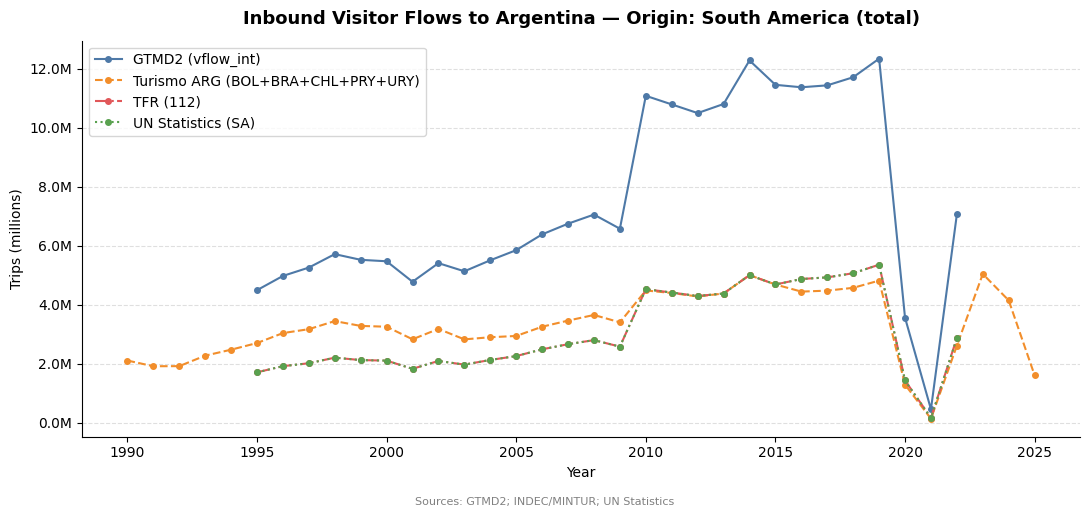

In [27]:
dest = "ARG"
sa_no_arg = [c for c in south_america if c != dest]

# GTMD2: suma todos los países SA hacia ARG
s_gtmd2_sa = (
    gtmd2[
        (gtmd2["iso3code_i"].isin(sa_no_arg)) &
        (gtmd2["iso3code_j"] == dest)
    ]
    .groupby("year")[["gtmd2_vflow_int", "unwto_tflow_112"]]
    .sum(min_count=1)
    .reset_index()
    .rename(columns={"gtmd2_vflow_int": "gtmd2", "unwto_tflow_112": "tfr_112"})
)

# Turismo ARG: suma los grupos con iso3 mapeado en SA
turismo_sa_isos = [iso for iso in sa_no_arg if iso in turismo_iso3.values()]
s_turismo_sa = (
    turismo_arg[turismo_arg["iso3code_i"].isin(turismo_sa_isos)]
    .groupby("year")["trips"]
    .sum()
    .reset_index()
    .rename(columns={"trips": "turismo_arg"})
)

# UN Latam: suma todos los países SA disponibles
s_un_sa = (
    un_latam[un_latam["iso3code_i"].isin(sa_no_arg)]
    .groupby("year")["un_latam_trips"]
    .sum()
    .reset_index()
)

tabla_sa = (
    s_gtmd2_sa
    .merge(s_turismo_sa, on="year", how="outer")
    .merge(s_un_sa,      on="year", how="outer")
    .sort_values("year")
    .reset_index(drop=True)
)

# Tabla formateada
tabla_sa_fmt = tabla_sa.copy()
for col in ["gtmd2", "tfr_112", "turismo_arg", "un_latam_trips"]:
    tabla_sa_fmt[col] = tabla_sa_fmt[col].apply(
        lambda x: f"{int(x):,}" if pd.notna(x) else "—"
    )
tabla_sa_fmt.columns = ["Year", "GTMD2 (vflow_int)", "TFR (112)", "Turismo ARG (INDEC/MINTUR)*", "UN Statistics"]
print("* Turismo ARG solo incluye: BOL, BRA, CHL, PRY, URY (únicos con mapeo individual)")
display(tabla_sa_fmt)

# Gráfico
plot_gtmd2(
    tabla_sa,
    [
        ("gtmd2",          "GTMD2 (vflow_int)",            "#4E79A7", "solid"),
        ("turismo_arg",    "Turismo ARG (BOL+BRA+CHL+PRY+URY)", "#F28E2B", "dashed"),
        ("tfr_112",        "TFR (112)",                    "#E15759", "dashdot"),
        ("un_latam_trips", "UN Statistics (SA)",           "#59A14F", "dotted"),
    ],
    "Inbound Visitor Flows to Argentina — Origin: South America (total)",
    caption="Sources: GTMD2; INDEC/MINTUR; UN Statistics",
)


## Otros corredores intra-LATAM

Para destinos distintos de Argentina solo están disponibles GTMD2 (vflow_int) y TFR (112).


  PER → CHL


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"454,478","182,208",—,—,—,—,—,—,—
1,1996,"391,106","155,298",—,—,—,—,—,—,—
2,1997,"495,562","199,785",—,—,—,—,—,—,—
3,1998,"450,905","180,684",—,—,—,—,—,—,—
4,1999,"314,086","122,974",—,—,—,—,—,—,—
5,2000,"382,970","151,863",—,—,—,—,—,—,—
6,2001,"347,824","137,077",—,—,—,—,—,—,—
7,2002,"390,026","154,842",—,—,—,—,—,—,—
8,2003,"411,001","163,718",—,—,—,—,—,—,—
9,2004,"463,567","186,088",—,—,—,—,—,—,—


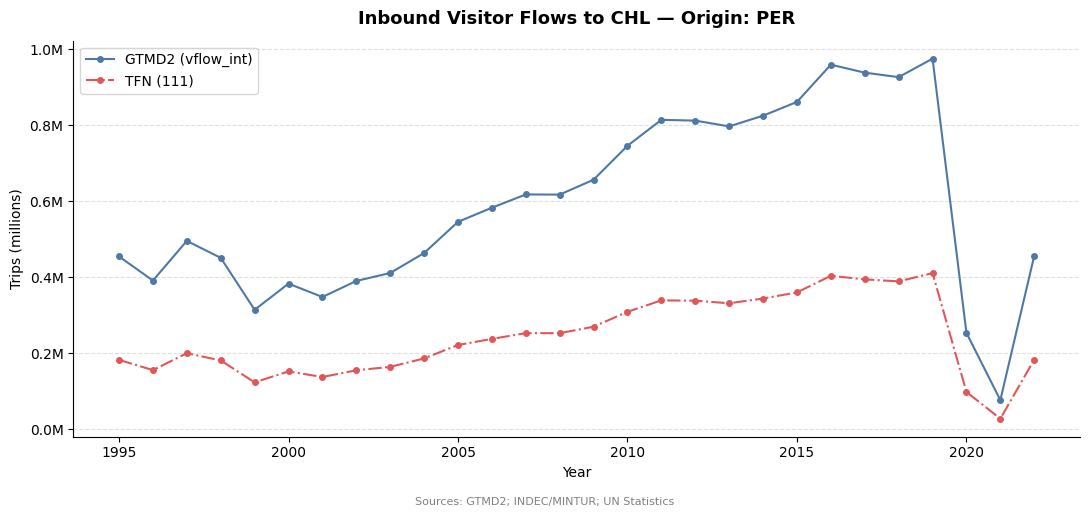


  PRY → BRA


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"224,036",—,"90,716",—,—,—,—,—,—
1,1996,"288,122",—,"118,563",—,—,—,—,—,—
2,1997,"351,685",—,"146,581",—,—,—,—,—,—
3,1998,"1,012,664",—,"451,693",—,—,—,—,—,—
4,1999,"1,117,106",—,"501,425",—,—,—,—,—,—
5,2000,"843,539",—,"371,873",—,—,—,—,—,—
6,2001,"658,498",—,"285,724",—,—,—,—,—,—
7,2002,"528,290",—,"226,011",—,—,—,—,—,—
8,2003,"466,897",—,"198,170",—,—,—,—,—,—
9,2004,"481,478",—,"204,762",—,—,—,—,—,—


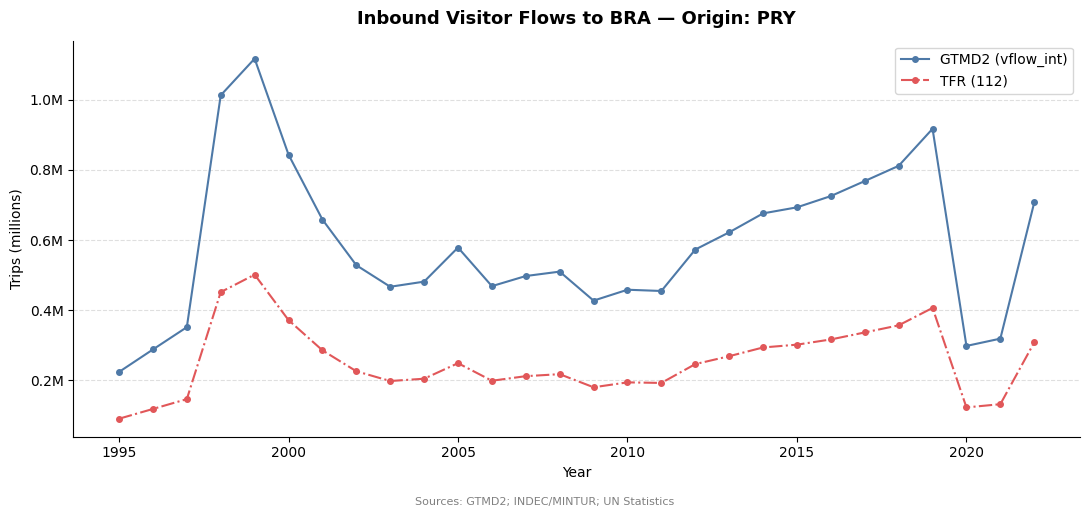


  COL → PER


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"44,198",—,"14,568",—,—,"30,421",—,—,—
1,1996,"52,777",—,"17,595",—,—,"25,250",—,—,—
2,1997,"60,273",—,"20,266",—,—,"28,547",—,—,—
3,1998,"58,564",—,"19,655",—,—,"28,291",—,—,—
4,1999,"56,344",—,"18,863",—,—,"31,721",—,—,—
5,2000,"71,589",—,"24,338",—,—,"34,212",—,—,—
6,2001,"76,779",—,"26,220",—,—,"31,957",—,—,—
7,2002,"93,807",—,"32,449",—,—,"38,954",—,—,—
8,2003,"97,423",—,"33,782",—,—,"63,997",—,—,—
9,2004,"113,470",—,"39,733",—,—,"69,488",—,—,—


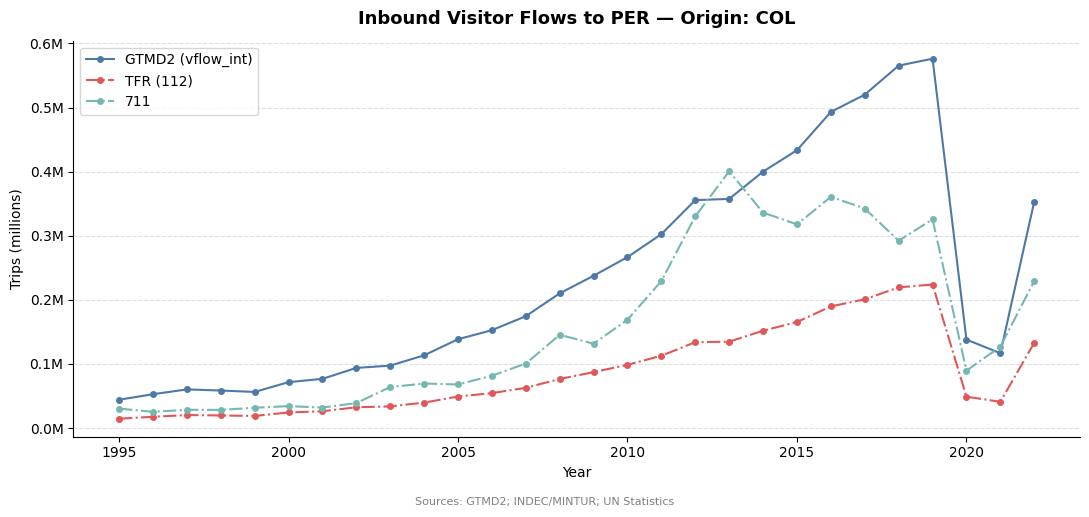


  COL → VEN


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"84,725","25,541",—,—,—,—,—,—,—
1,1996,"86,971","26,262",—,—,—,—,—,—,—
2,1997,"96,267","29,259",—,—,—,—,—,—,—
3,1998,"31,123","26,245",—,"31,123",—,—,—,—,—
4,1999,"29,358","24,543",—,"29,358",—,—,—,—,—
5,2000,"11,423","8,902",—,"11,423",—,—,—,—,—
6,2001,"27,132","20,029",—,"27,132",—,—,—,—,—
7,2002,"16,191","11,855",—,"16,191",—,—,—,—,—
8,2003,"13,665","10,576",—,"13,665",—,—,—,—,—
9,2004,"40,715","32,030",—,"40,715",—,—,—,—,—


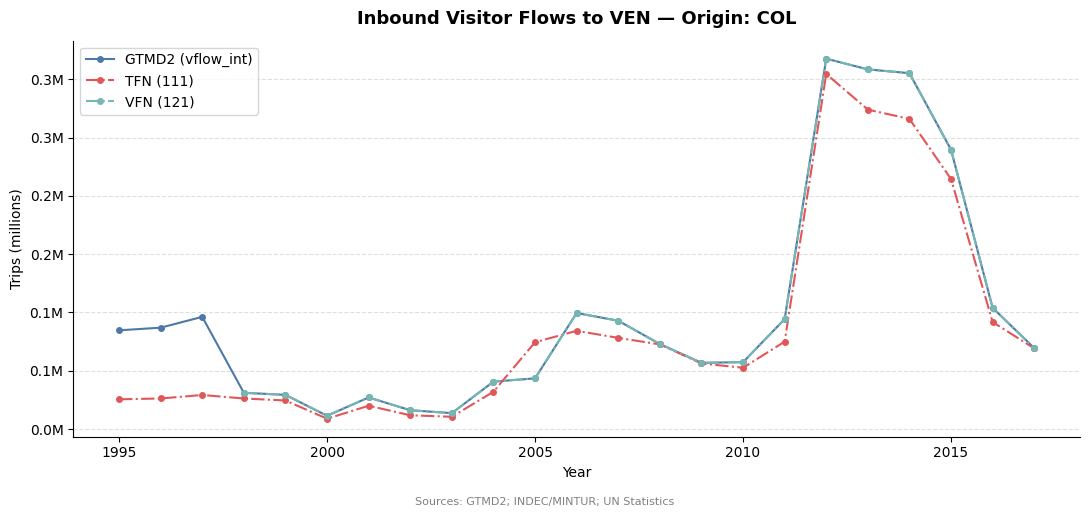


  PER → ECU


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"18,170",—,—,"18,170",—,—,—,—,—
1,1996,"34,795",—,—,"34,795",—,—,—,—,—
2,1997,"33,543",—,—,"33,543",—,—,—,—,—
3,1998,"29,821",—,—,"29,821",—,—,—,—,—
4,1999,"53,190",—,—,"53,190",—,—,—,—,—
5,2000,"90,727",—,—,"90,727",—,—,—,—,—
6,2001,"84,794",—,—,"84,794",—,—,—,—,—
7,2002,"106,777",—,—,"106,777",—,—,—,—,—
8,2003,"153,520",—,—,"153,520",—,—,—,—,—
9,2004,"191,303",—,—,"191,303",—,—,—,—,—


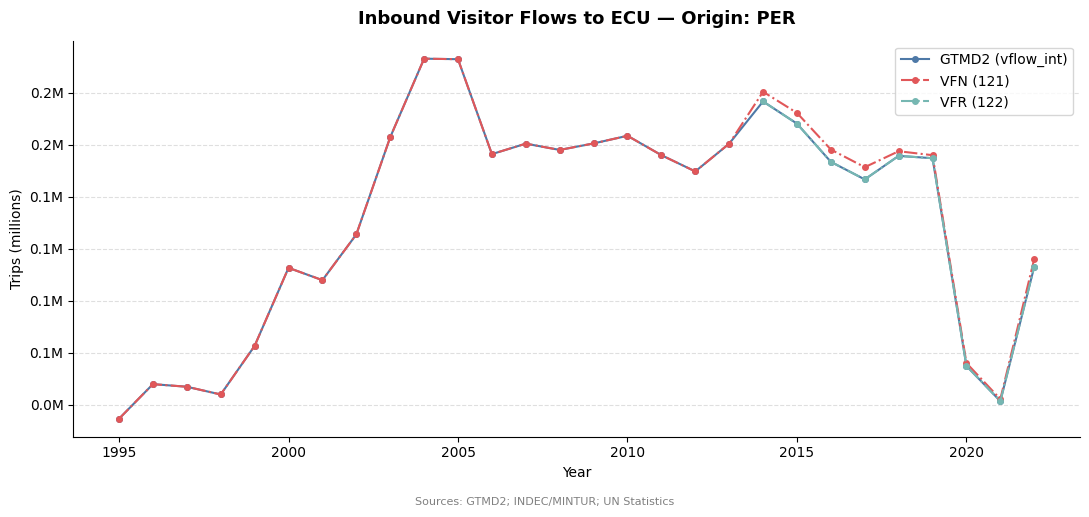


  ARG → URY


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"1,478,036",—,—,"1,478,036",—,—,—,—,—
1,1996,"1,491,845",—,—,"1,491,845",—,—,—,—,—
2,1997,"1,602,845",—,—,"1,602,845",—,—,—,—,—
3,1998,"1,513,634",—,—,"1,513,634",—,—,—,—,—
4,1999,"1,532,725",—,—,"1,532,725",—,—,—,—,—
5,2000,"1,510,386",—,—,"1,510,386",—,—,—,—,—
6,2001,"1,478,561",—,—,"1,478,561",—,—,—,—,—
7,2002,"813,304",—,—,"813,304",—,—,—,—,—
8,2003,"866,570",—,—,"866,570",—,—,—,—,—
9,2004,"1,108,592",—,—,"1,108,592",—,—,—,—,—


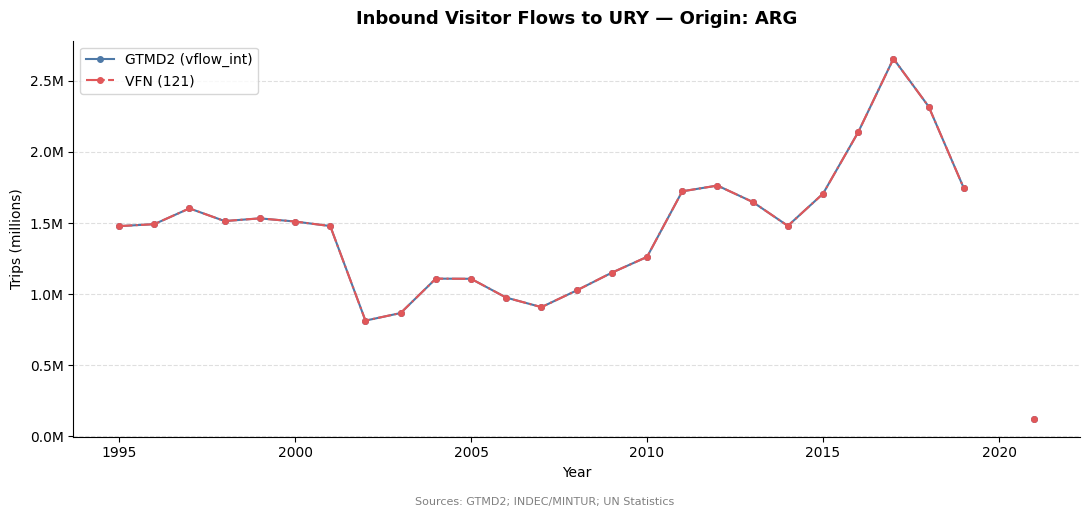

In [28]:
otros_corredores = [
    ("PER", "CHL"),
    ("PRY", "BRA"),
    ("COL", "PER"),
    ("COL", "VEN"),
    ("PER", "ECU"),
    ("ARG", "URY"),
]

for orig, dest in otros_corredores:
    print(f"\n{'='*60}")
    print(f"  {orig} → {dest}")
    print(f"{'='*60}")
    show_corredor(orig, dest)


## Venezuela → todos los países de Sudamérica

Solo GTMD2 (vflow_int) y TFR (112) disponibles para destinos distintos de Argentina.


  VEN → ARG


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912,Turismo ARG (INDEC/MINTUR),UN Statistics
0,1995,—,—,—,—,—,—,—,—,—,—,—
1,1996,—,—,—,—,—,—,—,—,—,—,—
2,1997,—,—,—,—,—,—,—,—,—,—,—
3,1998,—,—,—,—,—,—,—,—,—,—,—
4,1999,—,—,—,—,—,—,—,—,—,—,—
5,2000,—,—,—,—,—,—,—,—,—,—,—
6,2001,—,—,—,—,—,—,—,—,—,—,—
7,2002,—,—,—,—,—,—,—,—,—,—,—
8,2003,—,—,—,—,—,—,—,—,—,—,—
9,2004,—,—,—,—,—,—,—,—,—,—,—


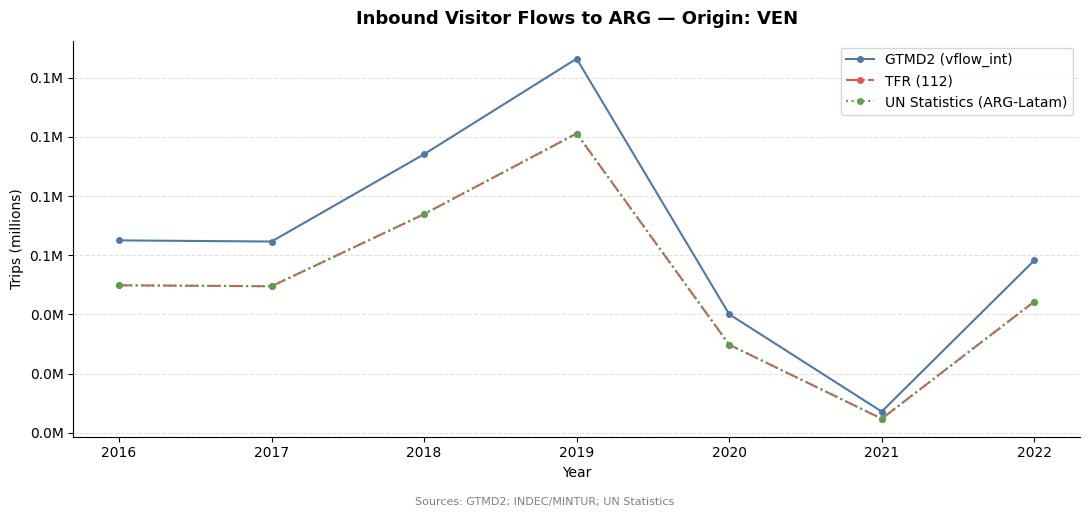


  VEN → BOL


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"5,483",—,—,—,—,"1,853",—,—,—
1,1996,"4,991",—,—,—,—,"1,645",—,—,—
2,1997,"5,955",—,—,—,—,"2,057",—,—,—
3,1998,"6,062",—,—,—,—,"2,104",—,—,—
4,1999,"6,030",—,—,—,—,"2,090",—,—,—
5,2000,"5,199",—,—,—,—,"1,732",—,—,—
6,2001,"5,941",—,—,—,—,"2,051",—,—,—
7,2002,"5,725",—,—,—,—,"1,957",—,—,—
8,2003,"5,623",—,—,—,—,"1,913",—,—,—
9,2004,"5,695",—,—,—,—,"1,944",—,—,—


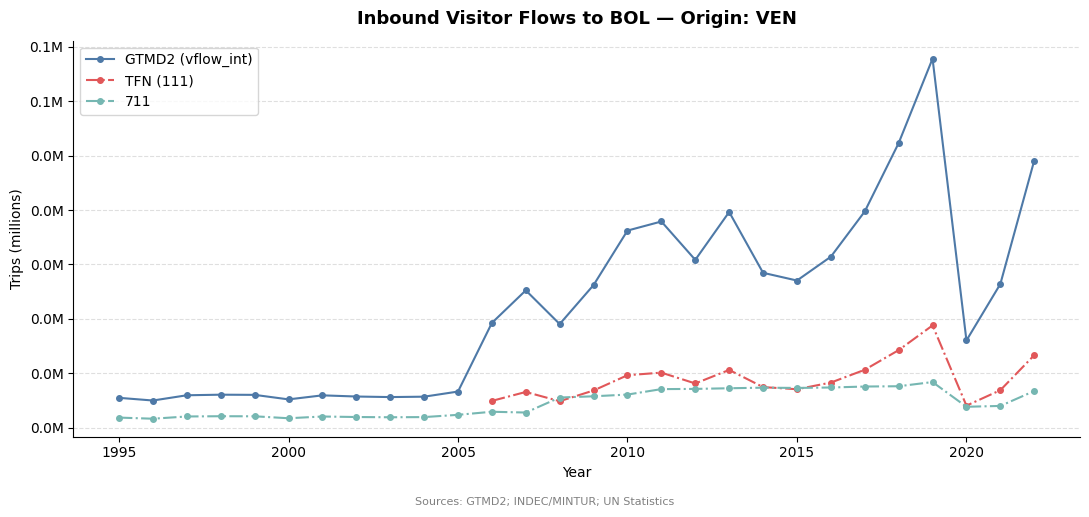


  VEN → BRA


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"76,093",—,"29,490",—,—,—,—,—,—
1,1996,"95,276",—,"37,461",—,—,—,—,—,—
2,1997,"72,036",—,"27,820",—,—,—,—,—,—
3,1998,"147,943",—,"59,834",—,—,—,—,—,—
4,1999,"145,958",—,"58,980",—,—,—,—,—,—
5,2000,"131,841",—,"52,929",—,—,—,—,—,—
6,2001,"124,412",—,"49,761",—,—,—,—,—,—
7,2002,"106,295",—,"42,088",—,—,—,—,—,—
8,2003,"99,508",—,"39,234",—,—,—,—,—,—
9,2004,"111,435",—,"44,257",—,—,—,—,—,—


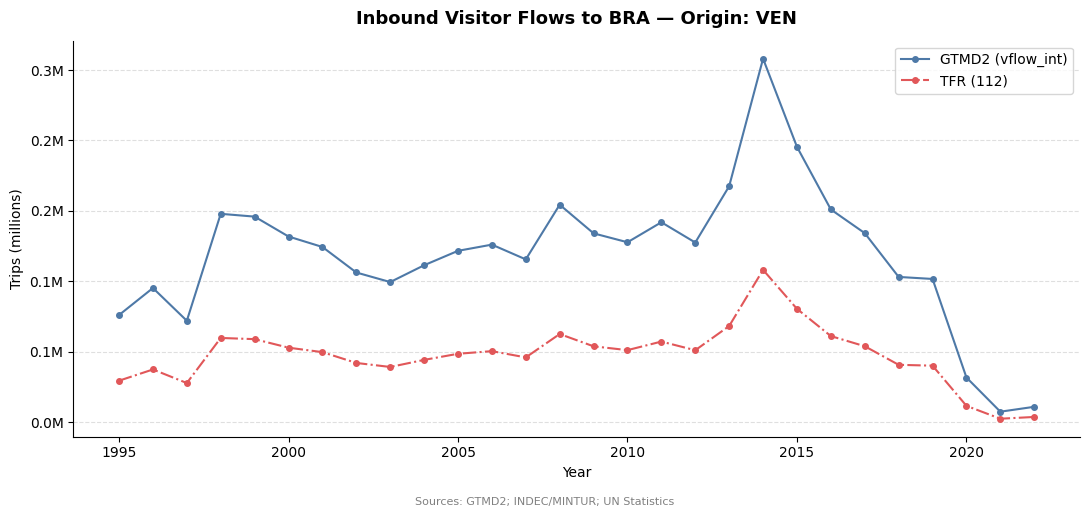


  VEN → CHL


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"11,561","7,927",—,—,—,—,—,—,—
1,1996,"12,213","8,403",—,—,—,—,—,—,—
2,1997,"11,742","8,059",—,—,—,—,—,—,—
3,1998,"13,124","9,072",—,—,—,—,—,—,—
4,1999,"12,387","8,531",—,—,—,—,—,—,—
5,2000,"13,053","9,020",—,—,—,—,—,—,—
6,2001,"14,046","9,752",—,—,—,—,—,—,—
7,2002,"11,911","8,182",—,—,—,—,—,—,—
8,2003,"15,110","10,540",—,—,—,—,—,—,—
9,2004,"16,499","11,574",—,—,—,—,—,—,—


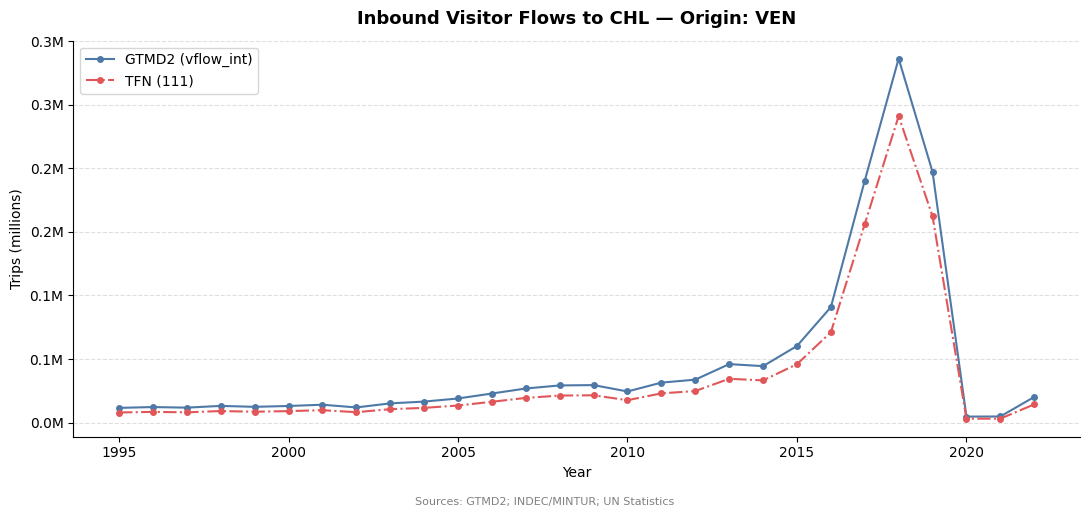


  VEN → COL


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"163,374",—,—,"163,374",—,—,—,—,—
1,1996,"43,549",—,—,"43,549",—,—,—,—,—
2,1997,"50,478",—,—,"50,478",—,—,—,—,—
3,1998,"62,727",—,—,"62,727",—,—,—,—,—
4,1999,"56,863",—,—,"56,863",—,—,—,—,—
5,2000,"62,195",—,—,"62,195",—,—,—,—,—
6,2001,"85,263",—,—,"85,263",—,—,—,—,—
7,2002,"65,781",—,—,"65,781",—,—,—,—,—
8,2003,"73,567",—,—,"73,567",—,—,—,—,—
9,2004,"92,523",—,—,"92,523",—,—,—,—,—


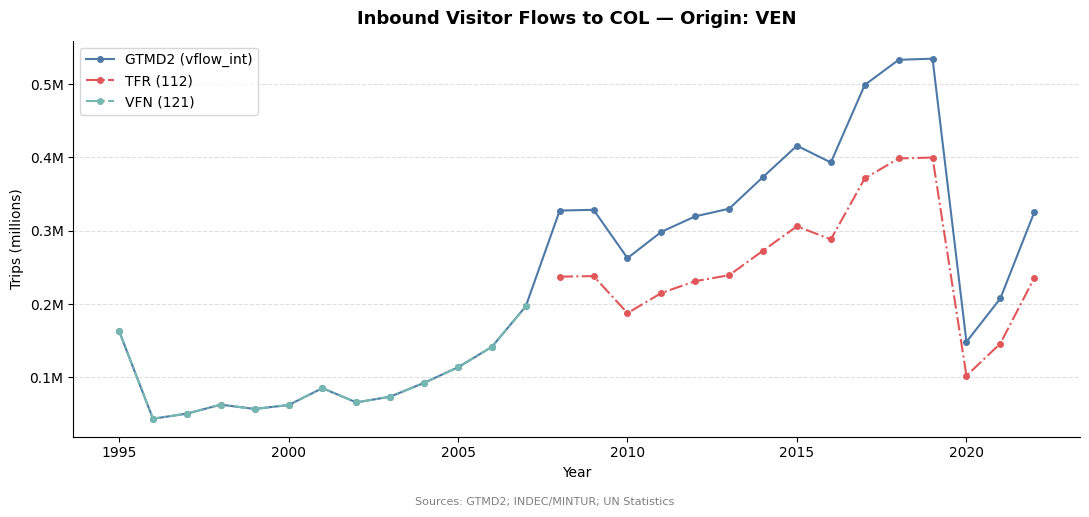


  VEN → ECU


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"10,815",—,—,"10,815",—,—,—,—,—
1,1996,"12,056",—,—,"12,056",—,—,—,—,—
2,1997,"12,148",—,—,"12,148",—,—,—,—,—
3,1998,"12,255",—,—,"12,255",—,—,—,—,—
4,1999,"10,540",—,—,"10,540",—,—,—,—,—
5,2000,"11,891",—,—,"11,891",—,—,—,—,—
6,2001,"14,089",—,—,"14,089",—,—,—,—,—
7,2002,"12,460",—,—,"12,460",—,—,—,—,—
8,2003,"14,084",—,—,"14,084",—,—,—,—,—
9,2004,"15,544",—,—,"15,544",—,—,—,—,—


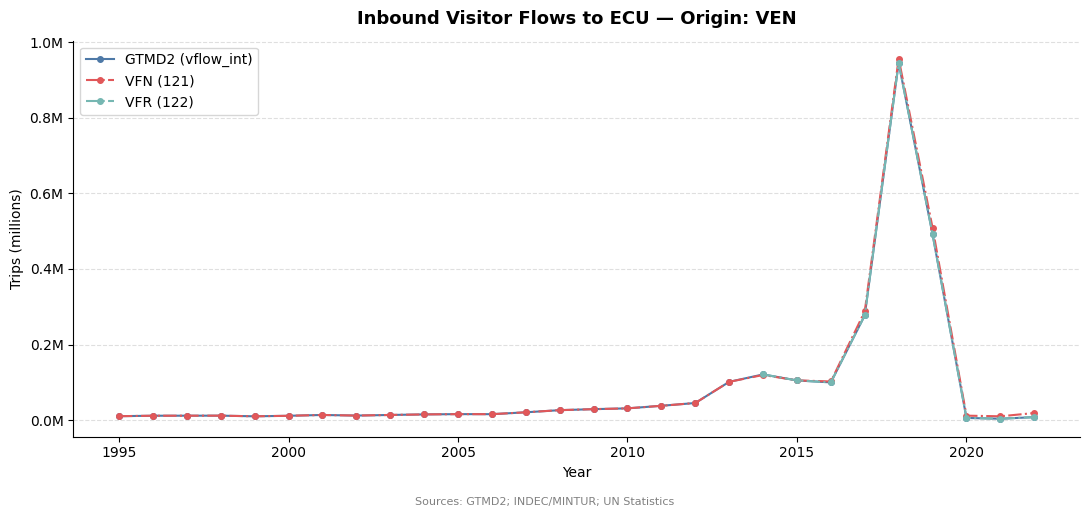


  VEN → GUY


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"2,627",—,774,—,—,—,—,—,—
1,1996,"2,484",—,729,—,—,—,—,—,—
2,1997,"1,328",—,374,—,—,—,—,—,—
3,1998,—,—,—,—,—,—,—,—,—
4,1999,—,—,—,—,—,—,—,—,—
5,2000,—,—,—,—,—,—,—,—,—
6,2001,—,—,—,—,—,—,—,—,—
7,2002,—,—,—,—,—,—,—,—,—
8,2003,—,—,—,—,—,—,—,—,—
9,2004,—,—,—,—,—,—,—,—,—


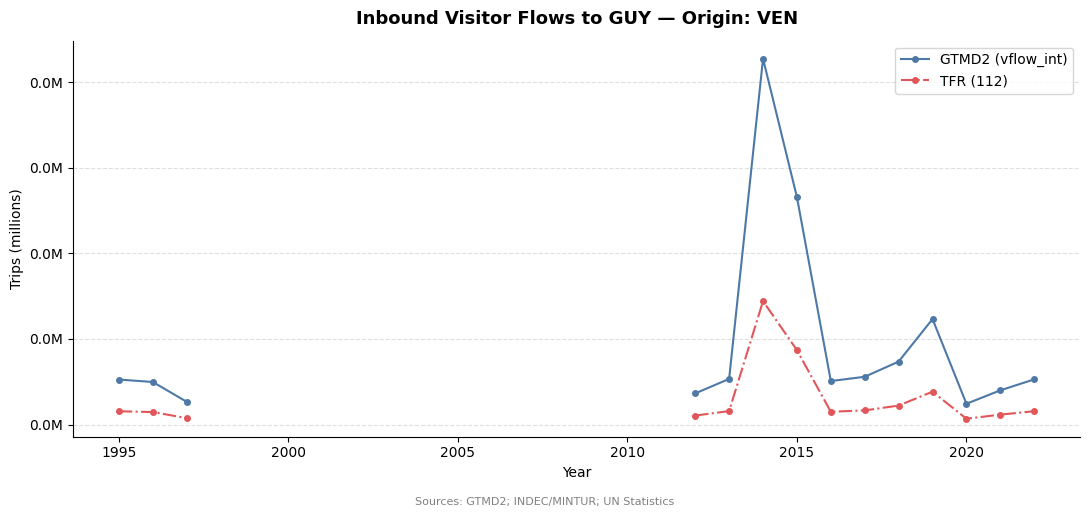


  VEN → PRY


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,—,—,—,—,—,—,—,—,—
1,1996,—,—,—,—,—,—,—,—,—
2,1997,"2,676",634,—,—,—,—,—,—,—
3,1998,"3,931",955,—,—,—,—,—,—,—
4,1999,"1,143",256,—,—,—,—,—,—,—
5,2000,—,—,—,—,—,—,—,—,—
6,2001,"2,481",585,—,—,—,—,—,—,—
7,2002,"1,512",345,—,—,—,—,—,—,—
8,2003,"1,770",408,—,—,—,—,—,—,—
9,2004,"3,301",793,—,—,—,—,—,—,—


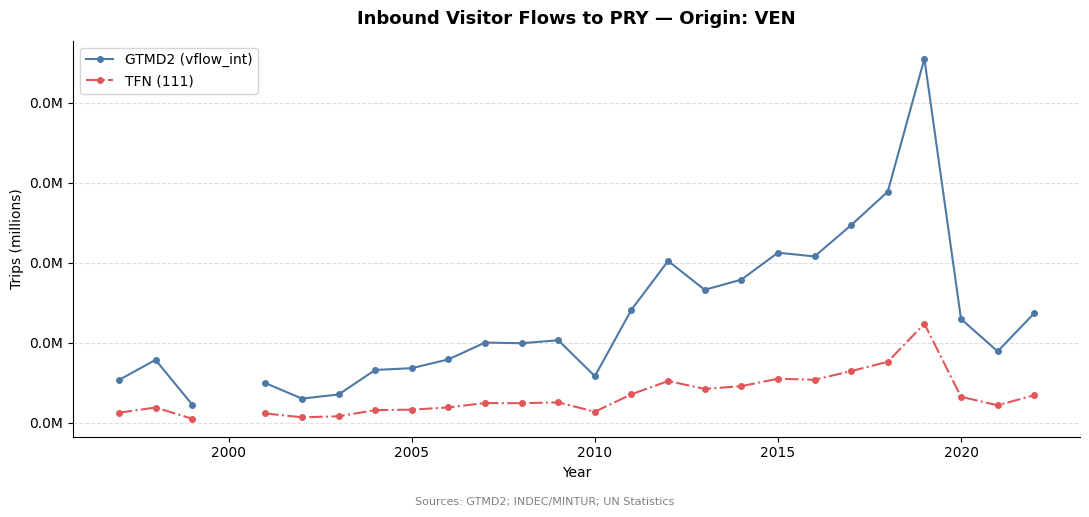


  VEN → PER


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"17,571",—,"11,072",—,—,"27,848",—,—,—
1,1996,"18,166",—,"11,472",—,—,"19,764",—,—,—
2,1997,"19,793",—,"12,568",—,—,"19,369",—,—,—
3,1998,"22,829",—,"14,629",—,—,"16,258",—,—,—
4,1999,"23,399",—,"15,018",—,—,"16,440",—,—,—
5,2000,"24,311",—,"15,642",—,—,"19,673",—,—,—
6,2001,"28,330",—,"18,408",—,—,"21,487",—,—,—
7,2002,"23,138",—,"14,840",—,—,"19,403",—,—,—
8,2003,"20,341",—,"12,939",—,—,"21,460",—,—,—
9,2004,"29,634",—,"19,311",—,—,"25,422",—,—,—


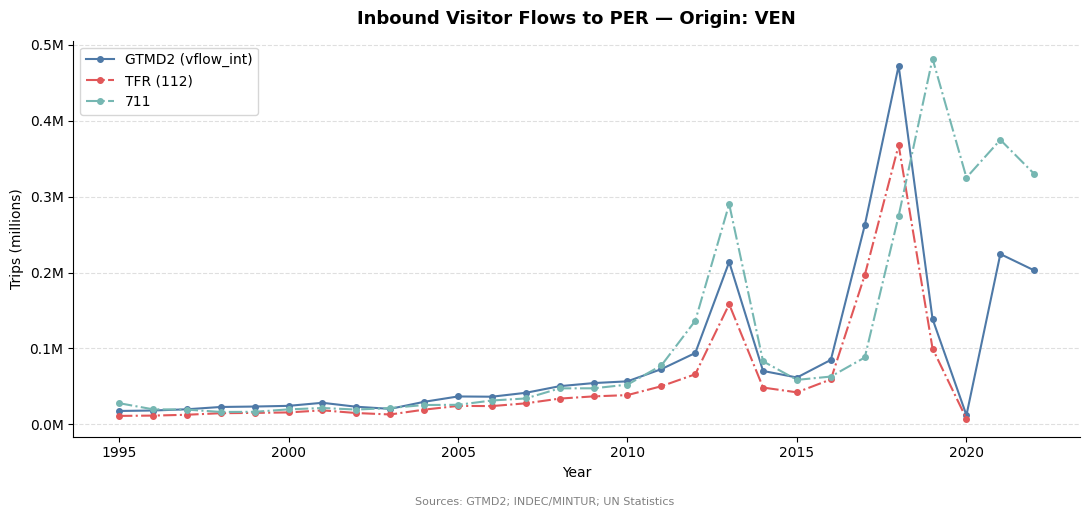


  VEN → SUR


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,492,—,263,—,—,—,—,—,—
1,1996,112,—,54,—,—,—,—,—,—
2,1997,103,—,49,—,—,—,—,—,—
3,1998,59,—,27,—,—,—,—,—,—
4,1999,37,—,16,—,—,—,—,—,—
5,2000,79,—,37,—,—,—,—,—,—
6,2001,133,—,65,—,—,—,—,—,—
7,2002,135,—,66,—,—,—,—,—,—
8,2003,293,—,151,—,—,—,—,—,—
9,2004,311,—,161,—,—,—,—,—,—


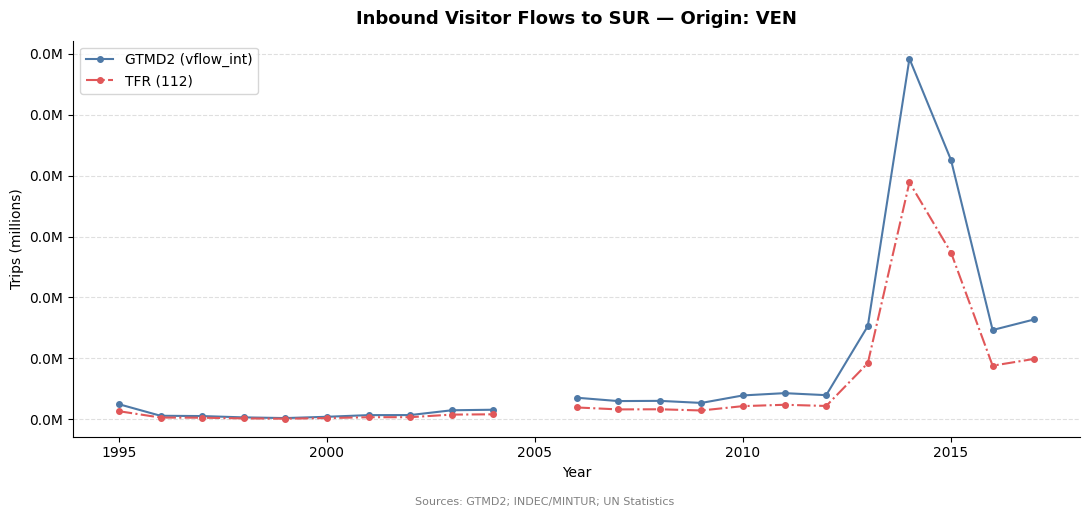


  VEN → URY


,Year,GTMD2 (vflow_int),TFN (111),TFR (112),VFN (121),VFR (122),711,712,1911,1912
0,1995,"2,271",—,—,"2,271",—,—,—,—,—
1,1996,—,—,—,—,—,—,—,—,—
2,1997,—,—,—,—,—,—,—,—,—
3,1998,—,—,—,—,—,—,—,—,—
4,1999,—,—,—,—,—,—,—,—,—
5,2000,"3,416",—,—,"3,416",—,—,—,—,—
6,2001,"3,442",—,—,"3,442",—,—,—,—,—
7,2002,"2,509",—,—,"2,509",—,—,—,—,—
8,2003,"3,093",—,—,"3,093",—,—,—,—,—
9,2004,"4,390",—,—,"4,390",—,—,—,—,—


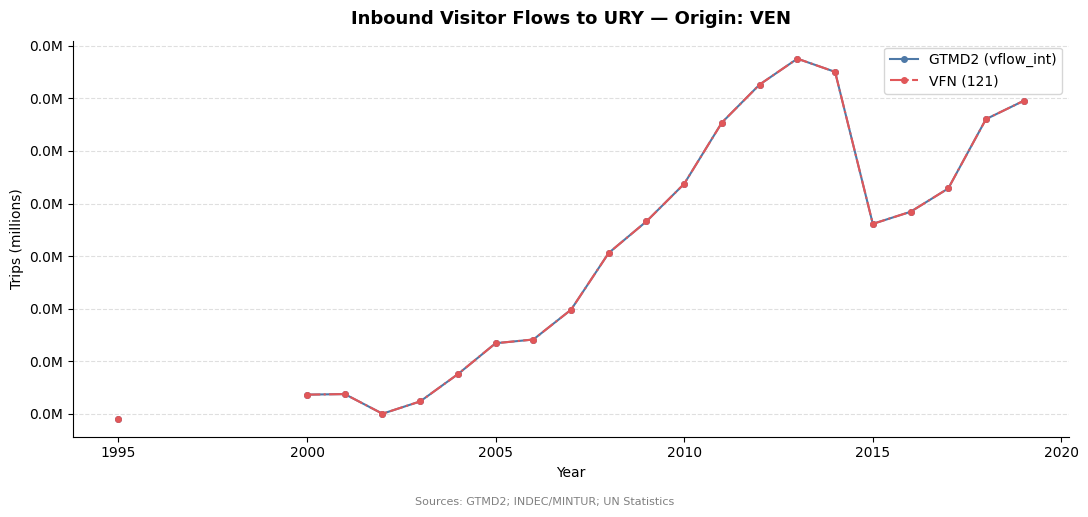

In [29]:
ven_destinations = [c for c in south_america if c != "VEN"]

for dest in ven_destinations:
    print(f"\n{'='*60}")
    print(f"  VEN → {dest}")
    print(f"{'='*60}")
    show_corredor("VEN", dest)
